# AI Tối Ưu Lịch Trình MTA — Single Route

Bản sao của `mta_schedule_optimization.ipynb`, **chỉ train/tối ưu trên 1 tuyến**.

Đổi tuyến tại biến `SINGLE_ROUTE_ID` trong cell Setup.


## 1. Setup & Imports

In [94]:
import os
import json
import warnings
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
import tensorflow as tf
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.callbacks import EarlyStopping

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

DATA_DIR = Path("../datasets")
OUT_DIR = Path("outputs_single_route")
OUT_DIR.mkdir(exist_ok=True)
import sys
sys.path.insert(0, str(Path(".").resolve()))

import importlib
import lib.single_route_pipeline as srp
importlib.reload(srp)
# build_demand_model qua srp trong cell model

# Chỉ train/tối ưu trên một tuyến (đổi tên tuyến tại đây)
SINGLE_ROUTE_ID = "1"

MANIFEST_FILE = DATA_DIR / "train_manifest.json"
if MANIFEST_FILE.exists():
    with open(MANIFEST_FILE, encoding="utf-8") as f:
        train_manifest = json.load(f)
else:
    train_manifest = {}

_DEFAULT_PATHS = {
    "ridership": "ridership.csv",
    "routes_by_station_complex": "routes_by_station_complex.csv",
    "routes": "routes.csv",
    "factors_hourly": "factors_hourly.csv",
    "schedule_dir": "schedule_current",
    "headway_by_route_hour": "headway_by_route_hour.csv",
    "factors_daily": "factors_daily.csv",
}

def data_path(key: str) -> Path:
    """Resolve a data path: manifest['paths'][key] -> fallback default name."""
    paths_cfg = train_manifest.get("paths", {}) or {}
    name = paths_cfg.get(key, _DEFAULT_PATHS.get(key, key))
    return DATA_DIR / name

# --- Đường dẫn (manifest paths nếu có, ngược lại default trong datasets/) ---
RIDERSHIP_FILE = data_path("ridership")
ROUTES_BY_COMPLEX_FILE = data_path("routes_by_station_complex")
FACTORS_HOURLY_FILE = data_path("factors_hourly")
SCHEDULE_DIR = data_path("schedule_dir")
HEADWAY_FILE = data_path("headway_by_route_hour")  # legacy aggregate (optional)

FACTORS_MODE = "hourly"  # bundle mới: factors_hourly là nguồn weather/calendar chính
FACTORS_JOIN_KEYS = ["date", "hour"]

_scope = train_manifest.get("scope", {})
OPT_HOURS = _scope.get("hours", list(range(24)))
OPT_ROUTE_MODE = _scope.get("route_mode", "headway")
DIRECTIONS = _scope.get("directions", [0, 1])
MIN_ROUTE_DEMAND_ROWS = 50
ROUTE_ALIASES = train_manifest.get("route_aliases", {"SIR": "SI"})
HEADWAY_SERVICE = "Weekday"  # service_id dùng để dựng baseline headway từ GTFS

COVERAGE_THR = 0.7
CHUNK_ROWS = 1_000_000  # file ridership.csv (~8.6 GB) — chunk lớn để giảm overhead
NN_EPOCHS_MAIN = 200
NN_EPOCHS_CV = 80
CV_SPLITS = 5

# --- NN tuning (single-route) ---
USE_ROUTE_EMBEDDING = False  # 1 tuyến → MLP thuần, không cần embedding
USE_LAG_FEATURES = True
LAG_FEATURE_COLS = ["log_lag_24h", "log_lag_168h", "log_rolling_7d"]
RESID_CLIP = (-0.4, 0.4)
TUNE_RESID_CLIP_ON_VAL = True
RESID_CLIP_CANDIDATES = [0.35, 0.45, 0.55]
PEAK_SAMPLE_WEIGHT = 2.0
NN_HIDDEN = (32, 16)
NN_DROPOUT = 0.30


LAMBDA_COST = 150.0
LAMBDA_GRID = [100, 150, 200, 400, 600, 1000]

# Giới hạn số chuyến so với baseline GTFS (tránh tăng trip quá mạnh)
TRIPS_MIN_FACTOR = 0.5
TRIPS_MAX_FACTOR = 1.25   # trước đây 1.5 — thu hẹp biên trên
TRIPS_MAX_DELTA = 3       # trước đây +5 — slot đêm baseline=3 → max 6 thay vì 8
LAMBDA_AUTO_CALIBRATE = True   # tự tăng λ nếu 100% slot dính TRIPS_MAX
TARGET_MAX_BIND_FRACTION = 0.50  # mục tiêu ≤50% slot ở trần (tránh λ quá cao)

# Chia demand NN theo tỷ lệ chuyến GTFS (proxy inbound/outbound)
SPLIT_DEMAND_BY_DIRECTION = True

# Auto-select policy for lambda tuning
# OPT_TARGET: "wait" | "cost" | "objective" | "balanced"
OPT_TARGET = "balanced"
BALANCED_WEIGHTS = {"wait": 0.6, "cost": 0.4}
LAMBDA_CANDIDATES = [60.0, 80.0, 100.0, 120.0, 150.0, 180.0, 220.0, 260.0]

USE_ANALYTICAL_OPT = True
GA_POP_SIZE = 80
GA_GENERATIONS = 120
TABU_ITERS = 400
GA_MAX_SLOTS = 200

# Cột thời tiết/lịch dùng cho NN (từ factors_hourly)
HOURLY_FACTOR_COLS = [
    "temperature_c", "apparent_temperature_c",
    "precipitation_mm", "rain_mm", "snowfall_cm",
    "windspeed_kmh", "windgusts_kmh",
    "is_rain", "is_snow", "is_severe_wind",
    "is_peak_morning", "is_peak_evening", "is_overnight",
    "is_major_event_window",
]

print("TensorFlow:", tf.__version__)
print("Data dir:", DATA_DIR.resolve())
print("Output dir:", OUT_DIR.resolve())
print("Manifest:", train_manifest.get("purpose", ""))
print("Factors mode:", FACTORS_MODE, "| join:", FACTORS_JOIN_KEYS)
for label, p in [
    ("ridership", RIDERSHIP_FILE),
    ("routes_by_station_complex", ROUTES_BY_COMPLEX_FILE),
    ("factors_hourly", FACTORS_HOURLY_FILE),
    ("schedule_current/", SCHEDULE_DIR),
]:
    print(f"  {label}: {'OK' if p.exists() else 'MISSING'} — {p.name}")
print(f"  headway aggregate (optional): "
      f"{'OK' if HEADWAY_FILE.exists() else 'absent — sẽ tự dựng từ GTFS'}")
print("Route aliases:", ROUTE_ALIASES)
print(f"Scope: {len(OPT_HOURS)}h, routes={OPT_ROUTE_MODE}, directions={DIRECTIONS}")
print(f"Headway baseline service: {HEADWAY_SERVICE}")
print(f"Optimizer: USE_ANALYTICAL_OPT={USE_ANALYTICAL_OPT}")


TensorFlow: 2.20.0
Data dir: D:\tranport-public\datasets
Output dir: D:\tranport-public\notebooks\outputs_single_route
Manifest: MTA subway detailed evaluation bundle
Factors mode: hourly | join: ['date', 'hour']
  ridership: OK — ridership.csv
  routes_by_station_complex: OK — routes_by_station_complex.csv
  factors_hourly: OK — factors_hourly.csv
  schedule_current/: OK — schedule_current
  headway aggregate (optional): absent — sẽ tự dựng từ GTFS
Route aliases: {'SIR': 'SI'}
Scope: 24h, routes=headway, directions=[0, 1]
Headway baseline service: Weekday
Optimizer: USE_ANALYTICAL_OPT=True


## 2. Load & Hợp nhất dữ liệu thực

Bộ dữ liệu trong [`datasets/`](../datasets/) — khoá join tại [`datasets/train_manifest.json`](../datasets/train_manifest.json):

- `ridership.csv` — nhu cầu theo giờ × ga (đọc theo chunk vì file lớn).
- `routes_by_station_complex.csv` — bảng map ga → tuyến GTFS.
- `routes.csv` — metadata tuyến GTFS.
- `schedule_current/{trips,stop_times,calendar,calendar_dates}.txt` — GTFS hiện tại; baseline headway được **tự dựng** từ đây (không còn file tổng hợp `headway_by_route_hour.csv`).
- `factors_hourly.csv` — thời tiết + lịch **theo giờ** (join `date` + `hour`).

**Merge**: ridership (chunked) → aggregate `(station_complex_id, date, hour)` → map sang route → join **factors_hourly** trên `(date, hour)`.

In [95]:
routes_complex = pd.read_csv(ROUTES_BY_COMPLEX_FILE)
routes_complex["station_complex_id"] = routes_complex["station_complex_id"].astype(str)

route_col = "gtfs_route_ids" if "gtfs_route_ids" in routes_complex.columns else "route_ids_gtfs"
station_to_routes = (
    routes_complex.assign(route=routes_complex[route_col].astype(str).str.split())
    .explode("route")
    .dropna(subset=["route"])
)
station_to_routes = station_to_routes[station_to_routes["route"] != ""]
station_to_routes = station_to_routes[["station_complex_id", "route"]].drop_duplicates()
station_to_routes["route"] = station_to_routes["route"].replace(ROUTE_ALIASES)

route_counts = station_to_routes.groupby("station_complex_id").size().rename("n_routes_at_station")
station_to_routes = station_to_routes.merge(route_counts, on="station_complex_id")
station_to_routes["weight"] = 1.0 / station_to_routes["n_routes_at_station"]

print("Tổng map station→route:", len(station_to_routes))
print("Số ga có map:", station_to_routes["station_complex_id"].nunique())
print("Số tuyến xuất hiện:", station_to_routes["route"].nunique())
station_to_routes.head()


Tổng map station→route: 767
Số ga có map: 445
Số tuyến xuất hiện: 26


,station_complex_id,route,n_routes_at_station,weight
0,1,N,2,0.5
1,1,W,2,0.5
2,2,N,2,0.5
3,2,W,2,0.5
4,3,N,2,0.5


In [96]:
usecols = ["transit_timestamp", "transit_mode", "station_complex_id", "ridership"]
valid_stations = set(station_to_routes["station_complex_id"].unique())

agg_parts = []
for chunk in pd.read_csv(
    RIDERSHIP_FILE,
    usecols=usecols,
    chunksize=CHUNK_ROWS,
    parse_dates=["transit_timestamp"],
    dtype={"station_complex_id": str},
):
    chunk = chunk[chunk["transit_mode"] == "subway"]
    chunk = chunk[chunk["station_complex_id"].isin(valid_stations)]
    if chunk.empty:
        continue
    chunk["date"] = chunk["transit_timestamp"].dt.date
    chunk["hour"] = chunk["transit_timestamp"].dt.hour
    grp = (
        chunk.groupby(["station_complex_id", "date", "hour"], as_index=False)["ridership"]
        .sum()
    )
    agg_parts.append(grp)

ridership_station = pd.concat(agg_parts, ignore_index=True)
print(f"Aggregated (station,date,hour) rows: {len(ridership_station):,}")
print("Date range:", ridership_station["date"].min(), "→", ridership_station["date"].max())


Aggregated (station,date,hour) rows: 7,296,927
Date range: 2024-01-01 → 2025-12-31


In [97]:
ridership_station = (
    ridership_station.groupby(["station_complex_id", "date", "hour"], as_index=False)["ridership"]
    .sum()
)

routed = ridership_station.merge(station_to_routes, on="station_complex_id", how="inner")
routed["ridership_route"] = routed["ridership"] * routed["weight"]

route_stations_total = station_to_routes.groupby("route").size().rename("n_stations_route")

agg = routed.groupby(["route", "date", "hour"]).agg(
    demand_observed=("ridership_route", "sum"),
    n_active=("station_complex_id", "nunique"),
).reset_index()
agg = agg.merge(route_stations_total, left_on="route", right_index=True)

agg["coverage"] = agg["n_active"] / agg["n_stations_route"]
agg = agg[agg["coverage"] >= COVERAGE_THR].copy()
agg["demand"] = agg["demand_observed"] / agg["coverage"]

ridership_route = agg[["route", "date", "hour", "demand", "coverage"]].rename(
    columns={"route": "route_id"}
)
ridership_route["date"] = pd.to_datetime(ridership_route["date"])

print(f"Total (route,date,hour) records (coverage≥{COVERAGE_THR}): {len(ridership_route):,}")
print(f"Coverage stats: mean={ridership_route['coverage'].mean():.2f}, "
      f"min={ridership_route['coverage'].min():.2f}, "
      f"max={ridership_route['coverage'].max():.2f}")
print(f"Unique dates: {ridership_route['date'].nunique()}")
ridership_route.head()

Total (route,date,hour) records (coverage≥0.7): 432,621
Coverage stats: mean=0.99, min=0.70, max=1.00
Unique dates: 731


,route_id,date,hour,demand,coverage
0,1,2024-01-01,0,7266.783333,1.0
1,1,2024-01-01,1,7454.916667,1.0
2,1,2024-01-01,2,4019.500000,1.0
3,1,2024-01-01,3,1874.133333,1.0
4,1,2024-01-01,4,1078.650000,1.0


In [98]:
def load_factors_hourly(path: Path) -> pd.DataFrame:
    """Load hourly weather/calendar; one row per (date, hour).
    Join key: ridership(date,hour) ↔ factors_hourly(date,hour) — chuẩn hoá từ
    SUBSTR(transit_timestamp,1,19) = timestamp (merge hint trong train_manifest.json).
    """
    fh = pd.read_csv(path, parse_dates=["timestamp", "date"])
    if "hour" not in fh.columns:
        fh["hour"] = fh["timestamp"].dt.hour
    keep = [
        "date", "hour", "day_of_week", "is_weekend", "is_us_holiday", "month",
        *HOURLY_FACTOR_COLS,
    ]
    keep = [c for c in keep if c in fh.columns]
    fh = fh[keep].drop_duplicates(subset=["date", "hour"]).copy()
    fh["date"] = pd.to_datetime(fh["date"]).dt.normalize()
    fh["hour"] = fh["hour"].astype(int)
    return fh


def _gtfs_time_to_minutes(t: str) -> float:
    """GTFS departure_time: HH:MM:SS, có thể >24h (qua nửa đêm)."""
    if not isinstance(t, str) or ":" not in t:
        return np.nan
    h, m, s = t.split(":")
    return int(h) * 60 + int(m) + int(s) / 60.0


def build_headway_from_gtfs(
    schedule_dir: Path,
    service_id: str = HEADWAY_SERVICE,
) -> pd.DataFrame:
    """Dựng baseline headway (route × direction × hour) từ schedule_current/*.txt.

    Quy ước:
      - Lấy giờ khởi hành đại diện = `departure_time` ở stop đầu tiên (stop_sequence nhỏ nhất).
      - Lọc trip theo `service_id` (default Weekday); nếu service đó không có dữ liệu thì fallback
        sang service đầu tiên có sẵn trong calendar.txt.
      - Giờ vượt 24 được mod 24 để khớp scope tối ưu 0..23.
      - Khi `direction_id` thiếu → mặc định 0.
    Trả về DataFrame: route_id, direction_id, hour, trip_count, avg_headway_min, min_headway_min.
    """
    schedule_dir = Path(schedule_dir)
    trips = pd.read_csv(
        schedule_dir / "trips.txt",
        dtype={"trip_id": str, "route_id": str, "service_id": str},
    )
    stop_times = pd.read_csv(
        schedule_dir / "stop_times.txt",
        dtype={"trip_id": str, "stop_id": str, "departure_time": str, "arrival_time": str},
        usecols=lambda c: c in {"trip_id", "stop_sequence", "departure_time", "arrival_time"},
    )

    cal_path = schedule_dir / "calendar.txt"
    available_services = trips["service_id"].dropna().unique().tolist()
    if cal_path.exists():
        cal = pd.read_csv(cal_path, dtype={"service_id": str})
        available_services = cal["service_id"].dropna().unique().tolist() or available_services
    if service_id not in available_services and available_services:
        service_id = available_services[0]

    trips_f = trips[trips["service_id"] == service_id].copy()
    if trips_f.empty:
        trips_f = trips.copy()

    if "direction_id" not in trips_f.columns:
        trips_f["direction_id"] = 0
    trips_f["direction_id"] = (
        pd.to_numeric(trips_f["direction_id"], errors="coerce").fillna(0).astype(int)
    )

    first_stop = (
        stop_times.sort_values(["trip_id", "stop_sequence"])
        .groupby("trip_id", as_index=False)
        .first()[["trip_id", "departure_time", "arrival_time"]]
    )
    first_stop["dep_str"] = first_stop["departure_time"].fillna(first_stop["arrival_time"])
    first_stop["dep_min"] = first_stop["dep_str"].apply(_gtfs_time_to_minutes)
    first_stop = first_stop.dropna(subset=["dep_min"])

    merged = trips_f[["trip_id", "route_id", "direction_id"]].merge(
        first_stop[["trip_id", "dep_min"]], on="trip_id", how="inner"
    )
    merged["hour"] = (merged["dep_min"] // 60).astype(int) % 24
    merged["route_id"] = merged["route_id"].astype(str)

    rows = []
    for (route, direction, hour), g in merged.groupby(["route_id", "direction_id", "hour"]):
        times = np.sort(g["dep_min"].to_numpy() % (24 * 60))
        n = int(len(times))
        if n <= 0:
            continue
        avg_hw = 60.0 / n
        if n >= 2:
            deltas = np.diff(times)
            deltas = deltas[deltas > 0]
            min_hw = float(np.min(deltas)) if deltas.size else avg_hw
        else:
            min_hw = avg_hw
        rows.append({
            "route_id": route,
            "direction_id": int(direction),
            "hour": int(hour),
            "trip_count": n,
            "avg_headway_min": float(avg_hw),
            "min_headway_min": float(min_hw),
        })

    hw = pd.DataFrame(rows).sort_values(["route_id", "direction_id", "hour"]).reset_index(drop=True)
    hw.attrs["service_id"] = service_id
    return hw


factors = load_factors_hourly(FACTORS_HOURLY_FILE)
print("Factors: hourly", factors.shape, "| cols:", len(factors.columns))

headway = build_headway_from_gtfs(SCHEDULE_DIR, service_id=HEADWAY_SERVICE)
headway["route_id"] = headway["route_id"].astype(str)
headway.to_csv(OUT_DIR / "headway_by_route_hour_derived.csv", index=False)

print(
    f"Headway dựng từ GTFS (service={headway.attrs.get('service_id', HEADWAY_SERVICE)}):",
    headway.shape,
)
print("Hours in headway:", sorted(headway["hour"].unique()))
print("Routes in headway:", headway["route_id"].nunique())
factors.head(3)


Factors: hourly (17544, 20) | cols: 20
Headway dựng từ GTFS (service=Weekday): (1182, 6)
Hours in headway: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23)]
Routes in headway: 29


,date,hour,day_of_week,is_weekend,is_us_holiday,month,temperature_c,apparent_temperature_c,precipitation_mm,rain_mm,snowfall_cm,windspeed_kmh,windgusts_kmh,is_rain,is_snow,is_severe_wind,is_peak_morning,is_peak_evening,is_overnight,is_major_event_window
0,2024-01-01,0,0,0,1,1,1.8,-1.6,0.1,0.0,0.07,7.4,12.2,0,0,0,0,0,1,1
1,2024-01-01,1,0,0,1,1,1.3,-2.3,0.0,0.0,0.00,8.7,12.2,0,0,0,0,0,1,1
2,2024-01-01,2,0,0,1,1,2.4,-1.4,0.0,0.0,0.00,10.4,15.5,0,0,0,0,0,1,1


In [99]:
ridership_route["date"] = pd.to_datetime(ridership_route["date"]).dt.normalize()
ridership_route["hour"] = ridership_route["hour"].astype(int)

ridership_all = ridership_route.merge(factors, on=FACTORS_JOIN_KEYS, how="left")
if "day_of_week" in ridership_all.columns:
    ridership_all["day_of_week"] = ridership_all["day_of_week"].fillna(
        ridership_all["date"].dt.dayofweek
    )
else:
    ridership_all["day_of_week"] = ridership_all["date"].dt.dayofweek
if "is_weekend" in ridership_all.columns:
    ridership_all["is_weekend"] = ridership_all["is_weekend"].fillna(
        (ridership_all["date"].dt.dayofweek >= 5).astype(int)
    )
else:
    ridership_all["is_weekend"] = (ridership_all["date"].dt.dayofweek >= 5).astype(int)
miss = ridership_all["temperature_c"].isna().mean() if "temperature_c" in ridership_all.columns else 1.0
print(f"Merge hourly on {FACTORS_JOIN_KEYS}: missing weather rows = {miss:.2%}")

num_cols = [
    "temperature_c", "apparent_temperature_c",
    "precipitation_mm", "rain_mm", "snowfall_cm",
    "windspeed_kmh", "windgusts_kmh",
]
flag_cols = [
    "is_us_holiday", "is_rain", "is_snow", "is_severe_wind",
    "is_peak_morning", "is_peak_evening", "is_overnight",
    "is_major_event_window",
]

for c in num_cols:
    if c not in ridership_all.columns:
        ridership_all[c] = 0.0
    ridership_all[c] = ridership_all[c].fillna(ridership_all[c].median())
for c in flag_cols:
    if c not in ridership_all.columns:
        ridership_all[c] = 0
    ridership_all[c] = ridership_all[c].fillna(0).astype(int)

print("Merged ridership shape:", ridership_all.shape)
print("Hours:", sorted(ridership_all["hour"].unique()))
ridership_all.head()


Merge hourly on ['date', 'hour']: missing weather rows = 0.00%
Merged ridership shape: (432621, 23)
Hours: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23)]


,route_id,date,hour,demand,coverage,day_of_week,is_weekend,is_us_holiday,month,temperature_c,...,snowfall_cm,windspeed_kmh,windgusts_kmh,is_rain,is_snow,is_severe_wind,is_peak_morning,is_peak_evening,is_overnight,is_major_event_window
0,1,2024-01-01,0,7266.783333,1.0,0,0,1,1,1.8,...,0.07,7.4,12.2,0,0,0,0,0,1,1
1,1,2024-01-01,1,7454.916667,1.0,0,0,1,1,1.3,...,0.00,8.7,12.2,0,0,0,0,0,1,1
2,1,2024-01-01,2,4019.500000,1.0,0,0,1,1,2.4,...,0.00,10.4,15.5,0,0,0,0,0,1,1
3,1,2024-01-01,3,1874.133333,1.0,0,0,1,1,2.7,...,0.00,9.2,15.5,0,0,0,0,0,1,1
4,1,2024-01-01,4,1078.650000,1.0,0,0,1,1,2.7,...,0.00,7.9,13.3,0,0,0,0,0,1,1


## 3. EDA & Chọn scope tuyến

Mục tiêu: mô tả demand theo giờ/tuyến, chọn **toàn bộ tuyến có baseline headway** (29 nếu Weekday GTFS đầy đủ) × **24 giờ** cho tối ưu (~1.392 slot khi đầy đủ).

In [100]:
HEADWAY_ROUTES = sorted(headway["route_id"].astype(str).unique())
route_row_counts = ridership_all.groupby("route_id").size()
RIDERSHIP_ROUTES = route_row_counts[route_row_counts >= MIN_ROUTE_DEMAND_ROWS].index.astype(str).tolist()

if OPT_ROUTE_MODE == "headway":
    OPT_ROUTES = HEADWAY_ROUTES
elif OPT_ROUTE_MODE == "intersection":
    OPT_ROUTES = sorted(set(HEADWAY_ROUTES) & set(RIDERSHIP_ROUTES))
else:
    OPT_ROUTES = RIDERSHIP_ROUTES

route_totals = (
    ridership_all.groupby("route_id")["demand"].mean().sort_values(ascending=False)
)
print("Top 12 tuyến theo demand TB/giờ:")
print(route_totals.head(12).round(0))
# --- Single-route scope ---
_single = str(SINGLE_ROUTE_ID).strip()
if _single not in OPT_ROUTES:
    raise ValueError(
        f"SINGLE_ROUTE_ID='{_single}' không có trong OPT_ROUTES. "
        f"Ví dụ hợp lệ: {OPT_ROUTES[:12]}..."
    )
OPT_ROUTES = [_single]
print(f"\n[Single route] Chỉ dùng tuyến: {OPT_ROUTES} (mode={OPT_ROUTE_MODE})")

df = ridership_all[ridership_all["route_id"].isin(OPT_ROUTES)].copy()
print(f"\nDataset NN: {len(df):,} bản ghi, {df['date'].nunique()} ngày, {df['hour'].nunique()} giờ")
print(f"Demand range: {df['demand'].min():.0f} – {df['demand'].max():.0f}")


Top 12 tuyến theo demand TB/giờ:
route_id
1    11422.0
6    10739.0
7     9820.0
R     8718.0
F     8589.0
C     7450.0
A     7063.0
M     6690.0
Q     6650.0
2     6449.0
L     6062.0
4     5952.0
Name: demand, dtype: float64

[Single route] Chỉ dùng tuyến: ['1'] (mode=headway)

Dataset NN: 17,537 bản ghi, 731 ngày, 24 giờ
Demand range: 245 – 42547


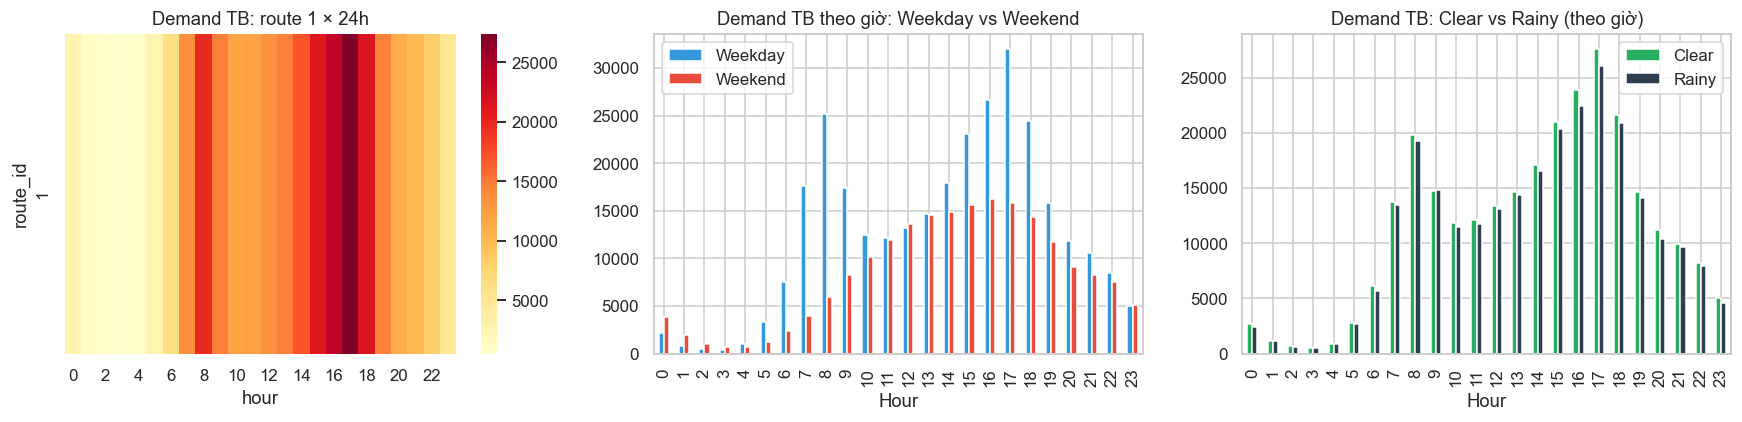

In [101]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Single-route notebook: chỉ vẽ các tuyến có trong df (thường là 1 tuyến)
plot_routes = [r for r in route_totals.head(12).index.astype(str) if r in df["route_id"].astype(str).unique()]
if not plot_routes:
    plot_routes = sorted(df["route_id"].astype(str).unique().tolist())

heat = df.groupby(["route_id", "hour"])["demand"].mean().unstack().loc[plot_routes]
sns.heatmap(heat, ax=axes[0], cmap="YlOrRd", annot=False)
axes[0].set_title(f"Demand TB: route {SINGLE_ROUTE_ID} × 24h")

wk = df.pivot_table(index="hour", columns="is_weekend", values="demand", aggfunc="mean")
wk = wk.rename(columns={0: "Weekday", 1: "Weekend"})
wk.plot(kind="bar", ax=axes[1], color=["#3498DB", "#E74C3C"])
axes[1].set_title("Demand TB theo giờ: Weekday vs Weekend")
axes[1].set_xlabel("Hour"); axes[1].legend()

rain_col = "is_rain" if "is_rain" in df.columns else "is_rainy_day"
rain = df.pivot_table(index="hour", columns=rain_col, values="demand", aggfunc="mean")
rain = rain.rename(columns={0: "Clear", 1: "Rainy"})
rain.plot(kind="bar", ax=axes[2], color=["#27AE60", "#2C3E50"])
axes[2].set_title("Demand TB: Clear vs Rainy (theo giờ)")
axes[2].set_xlabel("Hour"); axes[2].legend()

plt.tight_layout()
plt.savefig(OUT_DIR / "fig_eda.png", dpi=120, bbox_inches="tight")
plt.show()


**Quan sát** (full 24h × top tuyến):
- Demand thay đổi rõ theo giờ; peak sáng/chiều vẫn nổi bật trên tuyến trục.
- Weekend và ngày mưa lệch so weekday — NN dùng cho kịch bản.

In [102]:
df = df.sort_values(["route_id", "date", "hour"]).reset_index(drop=True)

df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
df["dow_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
df["dow_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)

route_to_idx = {r: i for i, r in enumerate(sorted(OPT_ROUTES))}
df["route_idx"] = df["route_id"].map(route_to_idx).astype(int)


def add_lag_features(d: pd.DataFrame) -> pd.DataFrame:
    """Lag cùng giờ: hôm qua, tuần trước, rolling 7 ngày (shift trong route×hour)."""
    if not USE_LAG_FEATURES:
        return d
    out = d.sort_values(["route_id", "hour", "date"]).copy()
    g = out.groupby(["route_id", "hour"])["demand"]
    out["demand_lag_24h"] = g.shift(1)
    out["demand_lag_168h"] = g.shift(7)
    out["demand_rolling_7d"] = g.transform(lambda s: s.shift(1).rolling(7, min_periods=1).mean())
    for raw, log_c in [
        ("demand_lag_24h", "log_lag_24h"),
        ("demand_lag_168h", "log_lag_168h"),
        ("demand_rolling_7d", "log_rolling_7d"),
    ]:
        out[log_c] = np.log1p(out[raw].clip(lower=0))
    return out.sort_values(["route_id", "date", "hour"]).reset_index(drop=True)


df = add_lag_features(df)

unique_dates = sorted(df["date"].unique())
n_dates = len(unique_dates)

rng = np.random.default_rng(SEED)
shuffled = rng.permutation(unique_dates)
n_train = int(n_dates * 0.70)
n_val = max(1, int(n_dates * 0.15))
train_dates = set(shuffled[:n_train])
val_dates   = set(shuffled[n_train:n_train + n_val])
test_dates  = set(shuffled[n_train + n_val:])

train_df = df[df["date"].isin(train_dates)].copy()
val_df   = df[df["date"].isin(val_dates)].copy()
test_df  = df[df["date"].isin(test_dates)].copy()

baseline_lookup = (
    train_df.groupby(["route_id", "hour", "is_weekend"])["demand"]
    .median()
    .rename("baseline_demand")
)
fallback = train_df.groupby(["route_id", "hour"])["demand"].median().rename("fallback_demand")


def attach_baseline(d: pd.DataFrame) -> pd.DataFrame:
    d = d.merge(baseline_lookup, on=["route_id", "hour", "is_weekend"], how="left")
    d = d.merge(fallback, on=["route_id", "hour"], how="left")
    d["baseline_demand"] = d["baseline_demand"].fillna(d["fallback_demand"])
    return d.drop(columns=["fallback_demand"])


def fill_lag_from_train(d: pd.DataFrame, ref: pd.DataFrame) -> pd.DataFrame:
    """Điền NaN lag bằng median train theo route×hour (tránh leakage)."""
    if not USE_LAG_FEATURES:
        return d
    lag_medians = (
        ref.groupby(["route_id", "hour"])[LAG_FEATURE_COLS]
        .median()
        .reset_index()
    )
    d = d.merge(lag_medians, on=["route_id", "hour"], how="left", suffixes=("", "_fill"))
    for c in LAG_FEATURE_COLS:
        fill_c = f"{c}_fill"
        if fill_c in d.columns:
            d[c] = d[c].fillna(d[fill_c])
            d = d.drop(columns=[fill_c])
        global_med = float(ref[c].median()) if c in ref.columns else 0.0
        d[c] = d[c].fillna(global_med)
    return d


train_df = attach_baseline(train_df)
val_df   = attach_baseline(val_df)
test_df  = attach_baseline(test_df)

train_df = fill_lag_from_train(train_df, train_df)
val_df   = fill_lag_from_train(val_df, train_df)
test_df  = fill_lag_from_train(test_df, train_df)

train_df["log_baseline"] = np.log1p(train_df["baseline_demand"])
val_df["log_baseline"]   = np.log1p(val_df["baseline_demand"])
test_df["log_baseline"]  = np.log1p(test_df["baseline_demand"])

NUM_FEATURES = [
    "hour_sin", "hour_cos", "dow_sin", "dow_cos",
    "is_weekend", "is_us_holiday",
    *HOURLY_FACTOR_COLS,
    "log_baseline",
]
if USE_LAG_FEATURES:
    NUM_FEATURES.extend(LAG_FEATURE_COLS)

lag_feature_defaults = {}
if USE_LAG_FEATURES:
    lag_med = train_df.groupby(["route_id", "hour"])[LAG_FEATURE_COLS].median()
    for (rid, hour), row in lag_med.iterrows():
        lag_feature_defaults[f"{rid}|{hour}"] = {c: float(row[c]) for c in LAG_FEATURE_COLS}

print(f"Random split theo ngày: {n_dates} ngày → train {len(train_dates)} / val {len(val_dates)} / test {len(test_dates)}")
print(f"Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}")
print(f"NUM_FEATURES ({len(NUM_FEATURES)}): embedding={'on' if USE_ROUTE_EMBEDDING else 'off'}, "
      f"lags={'on' if USE_LAG_FEATURES else 'off'}")

scaler = StandardScaler()
X_train_num = scaler.fit_transform(train_df[NUM_FEATURES])
X_val_num   = scaler.transform(val_df[NUM_FEATURES])
X_test_num  = scaler.transform(test_df[NUM_FEATURES])

X_train_route = train_df["route_idx"].values
X_val_route   = val_df["route_idx"].values
X_test_route  = test_df["route_idx"].values

y_train = (np.log1p(train_df["demand"].values) - train_df["log_baseline"].values)
y_val   = (np.log1p(val_df["demand"].values)   - val_df["log_baseline"].values)
y_test  = (np.log1p(test_df["demand"].values)  - test_df["log_baseline"].values)

print(f"Target (residual log demand) — train mean: {y_train.mean():+.3f}, std: {y_train.std():.3f}")

Random split theo ngày: 731 ngày → train 511 / val 109 / test 111
Train: 12,260 | Val: 2,614 | Test: 2,663
NUM_FEATURES (24): embedding=off, lags=on
Target (residual log demand) — train mean: -0.017, std: 0.216


In [103]:
import importlib
import lib.single_route_pipeline as srp
importlib.reload(srp)


def make_demand_model(n_routes: int, n_num_features: int) -> Model:
    """Factory NN — gọi trực tiếp module, tránh xung đột tên khi re-run cell."""
    return srp.build_demand_model(
        n_routes,
        n_num_features,
        use_route_embedding=USE_ROUTE_EMBEDDING,
        hidden=NN_HIDDEN,
        dropout=NN_DROPOUT,
    )


model = make_demand_model(len(route_to_idx), len(NUM_FEATURES))
model.summary()

Model: "functional_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ num_features (InputLayer)       │ (None, 24)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_0 (Dense)                 │ (None, 32)             │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_0 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_log_demand (Dense)     │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,345 (5.25 KB)

 Trainable params: 1,345 (5.25 KB)

 Non-trainable params: 0 (0.00 B)

In [104]:
def _fit_inputs(route_idx, num_feat):
    if USE_ROUTE_EMBEDDING:
        return {"route_idx": route_idx, "num_features": num_feat}
    return num_feat


train_weights = np.ones(len(train_df), dtype=float)
if PEAK_SAMPLE_WEIGHT > 1.0:
    peak_mask = (train_df["is_peak_morning"] == 1) | (train_df["is_peak_evening"] == 1)
    train_weights[peak_mask.to_numpy()] = PEAK_SAMPLE_WEIGHT
    print(f"Peak sample weight ×{PEAK_SAMPLE_WEIGHT}: {peak_mask.sum():,}/{len(train_df):,} rows")

early = EarlyStopping(monitor="val_loss", patience=25, restore_best_weights=True)
lr_reduce = tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=8, min_lr=1e-5)

history = model.fit(
    _fit_inputs(X_train_route, X_train_num),
    y_train,
    validation_data=(_fit_inputs(X_val_route, X_val_num), y_val),
    sample_weight=train_weights,
    epochs=NN_EPOCHS_MAIN,
    batch_size=32,
    verbose=0,
    callbacks=[early, lr_reduce],
)
print(f"Stop @ epoch {len(history.history['loss'])} | best val_mae={min(history.history['val_mae']):.4f}")

Peak sample weight ×2.0: 3,066/12,260 rows
Stop @ epoch 122 | best val_mae=0.0901


  val MAE @ clip ±0.35: 910.7
  val MAE @ clip ±0.45: 908.0
  val MAE @ clip ±0.55: 906.0
→ Chọn RESID_CLIP = ±0.55 (val MAE=906.0)
=== Hold-out test (split ngẫu nhiên theo ngày, 15%) ===
  Test: 2663 bản ghi, 111 ngày
  Baseline (median route×hour×weekend): MAE=1,912.3  R²=+0.850
  NN (residual, clip ±0.55 log):     MAE=1,122.1  R²=+0.945  MAPE=14.3%
  Δ MAE (baseline − NN): +41.32%


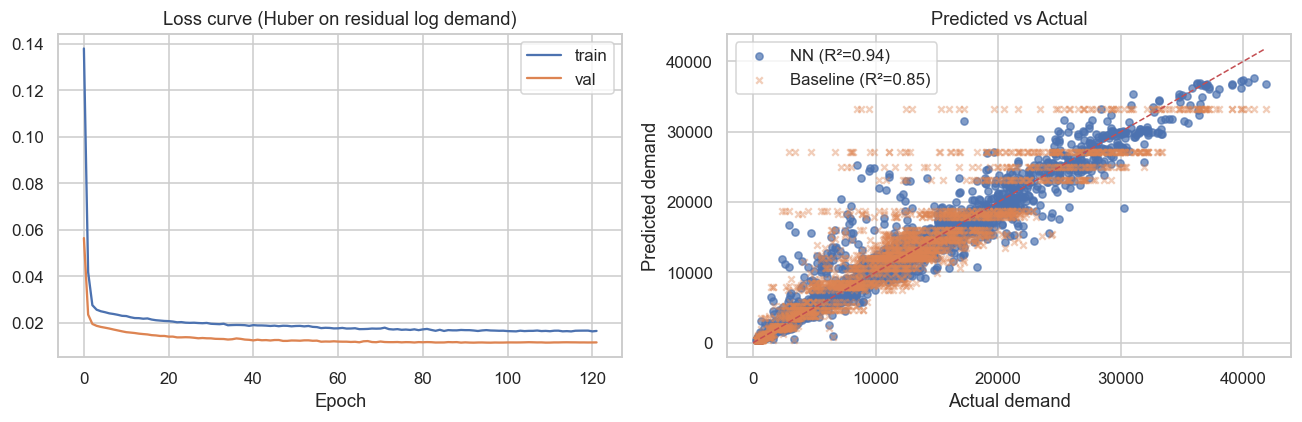

In [105]:
if TUNE_RESID_CLIP_ON_VAL:
    best_clip, best_mae = RESID_CLIP[1], float("inf")
    for clip_hi in RESID_CLIP_CANDIDATES:
        tmp_clip = (-clip_hi, clip_hi)
        pred_resid = model.predict(_fit_inputs(X_val_route, X_val_num), verbose=0).ravel()
        pred_resid = np.clip(pred_resid, *tmp_clip)
        pred_val = np.expm1(val_df["log_baseline"].values + pred_resid)
        mae_val = mean_absolute_error(val_df["demand"].values, pred_val)
        print(f"  val MAE @ clip ±{clip_hi:.2f}: {mae_val:,.1f}")
        if mae_val < best_mae:
            best_mae, best_clip = mae_val, clip_hi
    RESID_CLIP = (-best_clip, best_clip)
    print(f"→ Chọn RESID_CLIP = ±{best_clip:.2f} (val MAE={best_mae:,.1f})")


def predict_demand(route_idx_arr, num_feat_arr, log_baseline):
    """Predict raw demand: NN outputs residual log-demand, then multiply baseline."""
    pred_resid = model.predict(_fit_inputs(route_idx_arr, num_feat_arr), verbose=0).ravel()
    pred_resid = np.clip(pred_resid, *RESID_CLIP)
    pred_log = log_baseline + pred_resid
    return np.expm1(pred_log)

y_pred = predict_demand(X_test_route, X_test_num, test_df["log_baseline"].values)
y_true = test_df["demand"].values

baseline_pred_test = test_df["baseline_demand"].values
mae_baseline = mean_absolute_error(y_true, baseline_pred_test)
r2_baseline  = r2_score(y_true, baseline_pred_test)

mae = mean_absolute_error(y_true, y_pred)
mask = y_true > 100
mape = mean_absolute_percentage_error(y_true[mask], y_pred[mask]) if mask.sum() > 0 else np.nan
r2 = r2_score(y_true, y_pred)

improvement = (mae_baseline - mae) / mae_baseline * 100

nn_eval_metrics = {
    "holdout": {
        "n_test": int(len(test_df)),
        "n_test_dates": int(test_df["date"].nunique()),
        "mae_nn": float(mae),
        "mae_baseline": float(mae_baseline),
        "r2_nn": float(r2),
        "r2_baseline": float(r2_baseline),
        "mape_nn_pct": float(mape * 100) if not np.isnan(mape) else None,
        "mae_improvement_pct": float(improvement),
        "resid_clip": float(RESID_CLIP[1]),
    },
}

print("=== Hold-out test (split ngẫu nhiên theo ngày, 15%) ===")
print(f"  Test: {nn_eval_metrics['holdout']['n_test']} bản ghi, {nn_eval_metrics['holdout']['n_test_dates']} ngày")
print(f"  Baseline (median route×hour×weekend): MAE={mae_baseline:,.1f}  R²={r2_baseline:+.3f}")
print(f"  NN (residual, clip ±{RESID_CLIP[1]} log):     MAE={mae:,.1f}  R²={r2:+.3f}  MAPE={mape*100:.1f}%")
print(f"  Δ MAE (baseline − NN): {improvement:+.2f}%")
if improvement < 0:
    print("  → Hold-out: NN kém baseline trên split này; ưu tiên 5-fold CV khi báo cáo.")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history["loss"], label="train")
axes[0].plot(history.history["val_loss"], label="val")
axes[0].set_title("Loss curve (Huber on residual log demand)")
axes[0].set_xlabel("Epoch"); axes[0].legend()

axes[1].scatter(y_true, y_pred, alpha=0.7, s=22, label=f"NN (R²={r2:.2f})")
axes[1].scatter(y_true, baseline_pred_test, alpha=0.4, s=18, marker="x",
                 label=f"Baseline (R²={r2_baseline:.2f})")
lim = max(y_true.max(), y_pred.max(), baseline_pred_test.max())
axes[1].plot([0, lim], [0, lim], "r--", lw=1)
axes[1].set_xlabel("Actual demand"); axes[1].set_ylabel("Predicted demand")
axes[1].set_title("Predicted vs Actual")
axes[1].legend()

plt.tight_layout()
plt.savefig(OUT_DIR / "fig_nn_eval.png", dpi=120, bbox_inches="tight")
plt.show()

In [106]:
from sklearn.model_selection import KFold

all_df = add_lag_features(df.copy())
all_df = attach_baseline(all_df)
all_df = fill_lag_from_train(all_df, train_df)
all_df["log_baseline"] = np.log1p(all_df["baseline_demand"])

dates_arr = np.array(sorted(all_df["date"].unique()))
cv_splits = min(CV_SPLITS, max(2, len(dates_arr) - 1))
kf = KFold(n_splits=cv_splits, shuffle=True, random_state=SEED)

cv_mae_nn, cv_mae_base, cv_r2_nn, cv_r2_base = [], [], [], []
for fold, (tr_idx, te_idx) in enumerate(kf.split(dates_arr)):
    tr_dates, te_dates = set(dates_arr[tr_idx]), set(dates_arr[te_idx])
    tr_d = all_df[all_df["date"].isin(tr_dates)].copy()
    te_d = all_df[all_df["date"].isin(te_dates)].copy()
    if len(tr_d) == 0 or len(te_d) == 0:
        continue

    bl_lookup = (
        tr_d.groupby(["route_id", "hour", "is_weekend"])["demand"].median()
        .rename("baseline_demand_cv")
    )
    fb = tr_d.groupby(["route_id", "hour"])["demand"].median().rename("fb_demand")
    te_d = te_d.drop(columns=["baseline_demand", "log_baseline"], errors="ignore") \
                .merge(bl_lookup, on=["route_id", "hour", "is_weekend"], how="left") \
                .merge(fb, on=["route_id", "hour"], how="left")
    te_d["baseline_demand_cv"] = te_d["baseline_demand_cv"].fillna(te_d["fb_demand"])
    te_d = te_d.dropna(subset=["baseline_demand_cv"])
    te_d["log_baseline"] = np.log1p(te_d["baseline_demand_cv"])

    tr_d2 = tr_d.drop(columns=["baseline_demand", "log_baseline"], errors="ignore") \
                .merge(bl_lookup, on=["route_id", "hour", "is_weekend"], how="left") \
                .merge(fb, on=["route_id", "hour"], how="left")
    tr_d2["baseline_demand_cv"] = tr_d2["baseline_demand_cv"].fillna(tr_d2["fb_demand"])
    tr_d2 = tr_d2.dropna(subset=["baseline_demand_cv"])
    tr_d2["log_baseline"] = np.log1p(tr_d2["baseline_demand_cv"])

    sc = StandardScaler()
    Xt = sc.fit_transform(tr_d2[NUM_FEATURES])
    Xe = sc.transform(te_d[NUM_FEATURES])
    yt = np.log1p(tr_d2["demand"].values) - tr_d2["log_baseline"].values
    ye = te_d["demand"].values

    m = make_demand_model(len(route_to_idx), len(NUM_FEATURES))
    w_cv = np.ones(len(tr_d2), dtype=float)
    if PEAK_SAMPLE_WEIGHT > 1.0:
        pk = (tr_d2["is_peak_morning"] == 1) | (tr_d2["is_peak_evening"] == 1)
        w_cv[pk.to_numpy()] = PEAK_SAMPLE_WEIGHT
    m.fit(_fit_inputs(tr_d2["route_idx"].values, Xt), yt,
          sample_weight=w_cv, epochs=NN_EPOCHS_CV, batch_size=32, verbose=0,
          callbacks=[EarlyStopping(monitor="loss", patience=15, restore_best_weights=True)])
    pred_resid = m.predict(_fit_inputs(te_d["route_idx"].values, Xe),
                           verbose=0).ravel()
    pred_resid = np.clip(pred_resid, *RESID_CLIP)
    pred_nn = np.expm1(te_d["log_baseline"].values + pred_resid)
    pred_base = te_d["baseline_demand_cv"].values

    cv_mae_nn.append(mean_absolute_error(ye, pred_nn))
    cv_mae_base.append(mean_absolute_error(ye, pred_base))
    cv_r2_nn.append(r2_score(ye, pred_nn))
    cv_r2_base.append(r2_score(ye, pred_base))
    print(f"Fold {fold+1}: train {len(tr_dates)} dates / test {len(te_dates)} dates  "
          f"| NN MAE={cv_mae_nn[-1]:,.0f} (R²={cv_r2_nn[-1]:+.2f})  "
          f"| Baseline MAE={cv_mae_base[-1]:,.0f} (R²={cv_r2_base[-1]:+.2f})")

cv_impr = (np.mean(cv_mae_base) - np.mean(cv_mae_nn)) / np.mean(cv_mae_base) * 100
print("\n=== 5-fold CV summary (đáng tin hơn hold-out đơn) ===")
print(f"NN       avg MAE = {np.mean(cv_mae_nn):,.0f} ± {np.std(cv_mae_nn):,.0f}  | avg R² = {np.mean(cv_r2_nn):+.3f}")
print(f"Baseline avg MAE = {np.mean(cv_mae_base):,.0f} ± {np.std(cv_mae_base):,.0f}  | avg R² = {np.mean(cv_r2_base):+.3f}")
print(f"NN cải thiện trung bình so baseline: {cv_impr:+.1f}% MAE")

nn_cv_summary = {
    "n_folds": len(cv_mae_nn),
    "mae_nn_mean": float(np.mean(cv_mae_nn)),
    "mae_nn_std": float(np.std(cv_mae_nn)),
    "mae_baseline_mean": float(np.mean(cv_mae_base)),
    "mae_baseline_std": float(np.std(cv_mae_base)),
    "r2_nn_mean": float(np.mean(cv_r2_nn)),
    "r2_baseline_mean": float(np.mean(cv_r2_base)),
    "mae_improvement_pct": float(cv_impr),
}
nn_eval_metrics["cv"] = nn_cv_summary

nn_report = pd.DataFrame([
    {"metric": "MAE", "holdout_baseline": nn_eval_metrics["holdout"]["mae_baseline"],
     "holdout_nn": nn_eval_metrics["holdout"]["mae_nn"],
     "cv_mean_baseline": nn_cv_summary["mae_baseline_mean"],
     "cv_mean_nn": nn_cv_summary["mae_nn_mean"]},
    {"metric": "R²", "holdout_baseline": nn_eval_metrics["holdout"]["r2_baseline"],
     "holdout_nn": nn_eval_metrics["holdout"]["r2_nn"],
     "cv_mean_baseline": nn_cv_summary["r2_baseline_mean"],
     "cv_mean_nn": nn_cv_summary["r2_nn_mean"]},
])
print("\nBảng tổng hợp NN (hold-out vs CV):")
print(nn_report.round(3).to_string(index=False))
nn_report.to_csv(OUT_DIR / "nn_eval_summary.csv", index=False)
print("Đã lưu:", OUT_DIR / "nn_eval_summary.csv")


Fold 1: train 584 dates / test 147 dates  | NN MAE=861 (R²=+0.97)  | Baseline MAE=1,446 (R²=+0.93)
Fold 2: train 585 dates / test 146 dates  | NN MAE=1,024 (R²=+0.96)  | Baseline MAE=1,511 (R²=+0.92)
Fold 3: train 585 dates / test 146 dates  | NN MAE=1,140 (R²=+0.94)  | Baseline MAE=1,762 (R²=+0.88)
Fold 4: train 585 dates / test 146 dates  | NN MAE=1,003 (R²=+0.96)  | Baseline MAE=1,593 (R²=+0.91)
Fold 5: train 585 dates / test 146 dates  | NN MAE=967 (R²=+0.97)  | Baseline MAE=1,605 (R²=+0.90)

=== 5-fold CV summary (đáng tin hơn hold-out đơn) ===
NN       avg MAE = 999 ± 90  | avg R² = +0.961
Baseline avg MAE = 1,583 ± 106  | avg R² = +0.907
NN cải thiện trung bình so baseline: +36.9% MAE

Bảng tổng hợp NN (hold-out vs CV):
metric  holdout_baseline  holdout_nn  cv_mean_baseline  cv_mean_nn
   MAE          1912.288    1122.106          1583.378     999.165
    R²             0.850       0.945             0.907       0.961
Đã lưu: outputs_single_route\nn_eval_summary.csv


**Tổng kết Neural Network** (single route):
- MLP thuần (không embedding), lag 24h/168h/rolling-7d, trọng số giờ peak, tune `RESID_CLIP` trên val.
- Báo cáo hold-out và 5-fold CV (`nn_eval_summary.csv`).

## 5. Định nghĩa bài toán tối ưu hoá lịch trình

**Biến**: `trips[r,d,h]` cho mỗi slot trong `OPT_SCOPE` (48 slot = 1 tuyến × 2 hướng × 24 giờ).

**Mục tiêu**: min Σ (D·30/trips + λ·trips). Nghiệm analytical: `t* = sqrt(30·D/λ)` rồi clip `[TRIPS_MIN, TRIPS_MAX]`.

**Lưu ý quan trọng**: Nếu `t*` > `TRIPS_MAX` ở mọi slot thì lời giải = **trần biên** (mọi slot tăng trip tối đa cho phép), không phải nghiệm tự do. Khi đó đổi λ hoặc thu hẹp `TRIPS_MAX_FACTOR` / bật `LAMBDA_AUTO_CALIBRATE`.

**Kịch bản**: weekday_peak, weekend, rainy_day (`is_rain=1`).

In [107]:
OPT_SCOPE = [(r, d, h) for r in OPT_ROUTES for d in DIRECTIONS for h in OPT_HOURS]
N_SLOTS = len(OPT_SCOPE)
print(f"Scope tối ưu: {len(OPT_ROUTES)} tuyến × {len(DIRECTIONS)} hướng × {len(OPT_HOURS)} giờ = {N_SLOTS} slots")

slot_to_idx = {s: i for i, s in enumerate(OPT_SCOPE)}
slot_route = np.array([s[0] for s in OPT_SCOPE])
slot_dir   = np.array([s[1] for s in OPT_SCOPE])
slot_hour  = np.array([s[2] for s in OPT_SCOPE])

hw_lookup = headway.set_index(["route_id", "direction_id", "hour"])["trip_count"]
hw_rd_median = headway.groupby(["route_id", "direction_id"])["trip_count"].median()
hw_rh_median = headway.groupby(["route_id", "hour"])["trip_count"].median()
hw_hour_median = headway.groupby("hour")["trip_count"].median()
hw_global_median = float(headway["trip_count"].median())

n_fallback = 0
fallback_tiers = []
baseline_trips = np.zeros(N_SLOTS)
for i, (r, d, h) in enumerate(OPT_SCOPE):
    if (r, d, h) in hw_lookup.index:
        baseline_trips[i] = hw_lookup.loc[(r, d, h)]
        fallback_tiers.append(0)
    elif (r, d) in hw_rd_median.index:
        baseline_trips[i] = hw_rd_median.loc[(r, d)]
        fallback_tiers.append(1)
        n_fallback += 1
    elif (r, h) in hw_rh_median.index:
        baseline_trips[i] = hw_rh_median.loc[(r, h)]
        fallback_tiers.append(2)
        n_fallback += 1
    elif h in hw_hour_median.index:
        baseline_trips[i] = hw_hour_median.loc[h]
        fallback_tiers.append(3)
        n_fallback += 1
    else:
        baseline_trips[i] = hw_global_median
        fallback_tiers.append(4)
        n_fallback += 1

print(f"Baseline trips: mean={baseline_trips.mean():.1f}, "
      f"min={baseline_trips.min():.0f}, max={baseline_trips.max():.0f}")
print(f"Headway fallback: {n_fallback}/{N_SLOTS} slots "
      f"(tier 0=exact GTFS, 1=route×dir, 2=route×hour, 3=hour, 4=global)")

TRIPS_MIN = np.maximum(2, (baseline_trips * TRIPS_MIN_FACTOR)).astype(int)
TRIPS_MAX = np.minimum(60, (baseline_trips * TRIPS_MAX_FACTOR).astype(int))
TRIPS_MAX = np.maximum(TRIPS_MAX, baseline_trips.astype(int) + TRIPS_MAX_DELTA)
print(f"λ mặc định LAMBDA_COST = {LAMBDA_COST}")
print(f"TRIPS bounds: factor=[{TRIPS_MIN_FACTOR}, {TRIPS_MAX_FACTOR}], delta=+{TRIPS_MAX_DELTA}")
print(f"TRIPS_MIN range: [{TRIPS_MIN.min()}, {TRIPS_MIN.max()}]")
print(f"TRIPS_MAX range: [{TRIPS_MAX.min()}, {TRIPS_MAX.max()}]")
print(f"Baseline total trips/day: {baseline_trips.sum():.0f} | max allowed: {TRIPS_MAX.sum():.0f} "
      f"(+{(TRIPS_MAX.sum()/baseline_trips.sum()-1)*100:.0f}%)")
# Tỷ lệ demand theo chiều (proxy từ cơ cấu chuyến GTFS baseline)
_dir_df = pd.DataFrame({
    "route_id": slot_route,
    "direction_id": slot_dir,
    "hour": slot_hour,
    "base_trips": baseline_trips,
})
_dir_sum = _dir_df.groupby(["route_id", "hour"])["base_trips"].transform("sum").clip(lower=1e-6)
direction_share = (_dir_df["base_trips"] / _dir_sum).to_numpy(dtype=float)
print(
    f"Direction share (route×hour): min={direction_share.min():.2f}, max={direction_share.max():.2f}, "
    f"mean={direction_share.mean():.2f}"
)


Scope tối ưu: 1 tuyến × 2 hướng × 24 giờ = 48 slots
Baseline trips: mean=9.6, min=3, max=16
Headway fallback: 0/48 slots (tier 0=exact GTFS, 1=route×dir, 2=route×hour, 3=hour, 4=global)
λ mặc định LAMBDA_COST = 150.0
TRIPS bounds: factor=[0.5, 1.25], delta=+3
TRIPS_MIN range: [2, 8]
TRIPS_MAX range: [6, 20]
Baseline total trips/day: 462 | max allowed: 609 (+32%)
Direction share (route×hour): min=0.30, max=0.70, mean=0.50


In [108]:
def _scenario_context(scenario: str) -> tuple[int, int, float, int, int, pd.Series]:
    """Trả về (dow, is_weekend, rain_mm, is_rain, is_holiday, median factors)."""
    if scenario == "weekday_peak":
        dow, is_wkd = 1, 0
        rain_mm, is_rain, is_holiday = 0.0, 0, 0
        med = df.median(numeric_only=True)
    elif scenario == "weekend":
        dow, is_wkd = 5, 1
        rain_mm, is_rain, is_holiday = 0.0, 0, 0
        med = df.median(numeric_only=True)
    elif scenario == "rainy_day":
        dow, is_wkd = 1, 0
        is_holiday = 0
        rain_mask = pd.Series(False, index=df.index)
        if "is_rain" in df.columns:
            rain_mask = rain_mask | (df["is_rain"].fillna(0).astype(int) == 1)
        if "rain_mm" in df.columns:
            rain_mask = rain_mask | (pd.to_numeric(df["rain_mm"], errors="coerce").fillna(0) > 0)
        rain_ref = df[rain_mask] if rain_mask.any() else df
        rain_mm = float(pd.to_numeric(rain_ref.get("rain_mm", 0), errors="coerce").median())
        if not np.isfinite(rain_mm):
            rain_mm = 12.0
        is_rain = 1
        med = rain_ref.median(numeric_only=True)
    else:
        raise ValueError(scenario)
    return dow, is_wkd, rain_mm, is_rain, is_holiday, med


def build_scenario_features(scenario: str) -> pd.DataFrame:
    """Feature frame theo route×hour (một dòng / giờ / tuyến — không lặp chiều)."""
    dow, is_wkd, rain_mm, is_rain, is_holiday, med = _scenario_context(scenario)
    seen: set[tuple[str, int]] = set()
    rows = []
    for (r, _d, h) in OPT_SCOPE:
        key = (r, h)
        if key in seen:
            continue
        seen.add(key)
        row = dict(
            route_id=r, hour=h, day_of_week=dow,
            is_weekend=is_wkd, is_us_holiday=is_holiday,
            hour_sin=np.sin(2 * np.pi * h / 24), hour_cos=np.cos(2 * np.pi * h / 24),
            dow_sin=np.sin(2 * np.pi * dow / 7), dow_cos=np.cos(2 * np.pi * dow / 7),
        )
        row.update(
            temperature_c=float(med.get("temperature_c", 5.0)),
            apparent_temperature_c=float(med.get("apparent_temperature_c", 3.0)),
            precipitation_mm=float(med.get("precipitation_mm", rain_mm)) if is_rain else rain_mm,
            rain_mm=rain_mm,
            snowfall_cm=float(med.get("snowfall_cm", 0.0)),
            windspeed_kmh=float(med.get("windspeed_kmh", 15.0)),
            windgusts_kmh=float(med.get("windgusts_kmh", 25.0)),
            is_rain=is_rain, is_snow=int(med.get("is_snow", 0) > 0),
            is_severe_wind=int(med.get("is_severe_wind", 0) > 0),
            is_peak_morning=int(h in (7, 8, 9)),
            is_peak_evening=int(h in (17, 18, 19)),
            is_overnight=int(h <= 5 or h >= 23),
            is_major_event_window=int(med.get("is_major_event_window", 0) > 0),
        )
        if USE_LAG_FEATURES:
            defaults = lag_feature_defaults.get(f"{r}|{h}", {})
            row.update(
                log_lag_24h=float(defaults.get("log_lag_24h", 0.0)),
                log_lag_168h=float(defaults.get("log_lag_168h", 0.0)),
                log_rolling_7d=float(defaults.get("log_rolling_7d", 0.0)),
            )
        rows.append(row)
    feat = pd.DataFrame(rows)
    feat["route_idx"] = feat["route_id"].map(route_to_idx).astype(int)
    return feat


def _predict_route_hour_demand(feat_rh: pd.DataFrame) -> pd.DataFrame:
    """Dự báo demand route×hour; trả về cột route_id, hour, demand."""
    bl = feat_rh.merge(baseline_lookup, on=["route_id", "hour", "is_weekend"], how="left")
    bl = bl.merge(fallback, on=["route_id", "hour"], how="left")

    fb_route = (
        df.groupby(["route_id", "is_weekend"], as_index=False)["demand"]
        .median().rename(columns={"demand": "fb_route_weekend"})
    )
    fb_hour = (
        df.groupby(["hour", "is_weekend"], as_index=False)["demand"]
        .median().rename(columns={"demand": "fb_hour_weekend"})
    )
    fb_global = float(pd.to_numeric(df["demand"], errors="coerce").dropna().median())
    if not np.isfinite(fb_global) or fb_global <= 0:
        fb_global = 100.0

    bl = bl.merge(fb_route, on=["route_id", "is_weekend"], how="left")
    bl = bl.merge(fb_hour, on=["hour", "is_weekend"], how="left")
    bl["baseline_demand"] = (
        pd.to_numeric(bl["baseline_demand"], errors="coerce")
        .fillna(bl["fallback_demand"])
        .fillna(bl["fb_route_weekend"])
        .fillna(bl["fb_hour_weekend"])
        .fillna(fb_global)
        .clip(lower=1e-6)
    )

    for c in NUM_FEATURES:
        if c == "log_baseline":
            continue
        if c not in bl.columns:
            bl[c] = 0.0
        bl[c] = pd.to_numeric(bl[c], errors="coerce")
        med = float(pd.to_numeric(df[c], errors="coerce").median()) if c in df.columns else 0.0
        bl[c] = bl[c].fillna(med if np.isfinite(med) else 0.0)

    bl["log_baseline"] = np.log1p(bl["baseline_demand"])
    Xn = scaler.transform(bl[NUM_FEATURES])
    pred = predict_demand(bl["route_idx"].values, Xn, bl["log_baseline"].values)
    fill = float(np.nanmedian(bl["baseline_demand"]))
    pred = np.clip(np.nan_to_num(pred, nan=fill), 0.0, None)
    return bl[["route_id", "hour"]].assign(demand=pred)


def allocate_demand_to_slots(route_hour: pd.DataFrame) -> np.ndarray:
    """Map demand route×hour → 48 slot; chia theo direction_share nếu bật."""
    rh = route_hour.set_index(["route_id", "hour"])["demand"]
    out = np.zeros(N_SLOTS, dtype=float)
    for i, (r, _d, h) in enumerate(OPT_SCOPE):
        d_rh = float(rh.get((r, h), np.nan))
        if not np.isfinite(d_rh):
            d_rh = float(rh.mean()) if len(rh) else 100.0
        if SPLIT_DEMAND_BY_DIRECTION:
            out[i] = d_rh * direction_share[i]
        else:
            out[i] = d_rh / max(len(DIRECTIONS), 1)
    return out


def get_scenario_demand(scenario: str) -> np.ndarray:
    feat_rh = build_scenario_features(scenario)
    route_hour = _predict_route_hour_demand(feat_rh)
    return allocate_demand_to_slots(route_hour)


SCENARIOS = ["weekday_peak", "weekend", "rainy_day"]
scenario_demand = {s: get_scenario_demand(s) for s in SCENARIOS}

_chk = build_scenario_features("rainy_day").iloc[0]
assert _chk["is_rain"] == 1
print("✓ rainy_day: is_rain=1, rain_mm=", float(_scenario_context("rainy_day")[2]))

scen_df = pd.DataFrame({s: scenario_demand[s] for s in SCENARIOS})
scen_df.insert(0, "hour", slot_hour)
scen_df.insert(0, "dir", slot_dir)
scen_df.insert(0, "route", slot_route)

# Kiểm tra demand khác nhau giữa 2 chiều (cùng giờ)
_dir_cmp = scen_df.groupby(["hour", "dir"])["weekday_peak"].mean().unstack()
if _dir_cmp.shape[1] >= 2:
    ratio = (_dir_cmp.iloc[:, 1] / _dir_cmp.iloc[:, 0].clip(lower=1)).replace([np.inf], np.nan)
    print(f"Demand dir1/dir0 (weekday_peak, TB): min={ratio.min():.2f}, max={ratio.max():.2f}")

hour_agg = scen_df.groupby("hour")[SCENARIOS].mean().round(0)
print("\nDemand TB theo giờ (passengers/hour/slot, 3 kịch bản):")
print(hour_agg.head(8), "\n...", hour_agg.tail(3))
_ratio = scenario_demand["rainy_day"] / np.maximum(scenario_demand["weekday_peak"], 1e-9)
print("\nRainy / weekday_peak (TB):", round(float(_ratio.mean()), 3))


✓ rainy_day: is_rain=1, rain_mm= 0.3
Demand dir1/dir0 (weekday_peak, TB): min=0.60, max=2.33

Demand TB theo giờ (passengers/hour/slot, 3 kịch bản):
      weekday_peak  weekend  rainy_day
hour                                  
0           1054.0   1780.0     1054.0
1            386.0    822.0      386.0
2            222.0    443.0      222.0
3            214.0    314.0      213.0
4            499.0    425.0      498.0
5           1787.0    763.0     1801.0
6           4105.0   1439.0     4129.0
7           9804.0   2421.0     9890.0 
...       weekday_peak  weekend  rainy_day
hour                                  
21          5357.0   4852.0     5361.0
22          4301.0   4333.0     4301.0
23          2332.0   2846.0     2326.0

Rainy / weekday_peak (TB): 1.005


In [109]:
def evaluate_schedule(
    trips: np.ndarray,
    demand: np.ndarray,
    lambda_cost: float | None = None,
) -> dict:
    """Tính chỉ số lịch trình; lambda_cost=None → dùng LAMBDA_COST global."""
    lam = LAMBDA_COST if lambda_cost is None else float(lambda_cost)

    trips = np.asarray(trips, dtype=float)
    demand = np.asarray(demand, dtype=float)
    trips = np.nan_to_num(trips, nan=1.0, posinf=60.0, neginf=1.0)
    demand = np.nan_to_num(demand, nan=0.0, posinf=0.0, neginf=0.0)
    trips = np.maximum(trips, 1)
    demand = np.clip(demand, 0.0, None)

    headway_min = 60.0 / trips
    avg_wait_min = headway_min / 2.0
    passenger_min_wait = demand * avg_wait_min
    total_wait = passenger_min_wait.sum()
    weighted_avg_wait = total_wait / max(demand.sum(), 1e-9)
    total_fleet_cost = lam * trips.sum()
    return dict(
        total_passenger_min_wait=float(total_wait),
        weighted_avg_wait_min=float(weighted_avg_wait),
        total_fleet_cost=float(total_fleet_cost),
        total_trips=float(trips.sum()),
        headway_std=float(headway_min.std()),
        objective=float(total_wait + total_fleet_cost),
        lambda_cost=lam,
    )

def objective(trips: np.ndarray, demand: np.ndarray, lambda_cost: float | None = None) -> float:
    return evaluate_schedule(trips, demand, lambda_cost=lambda_cost)["objective"]

def optimize_schedule_analytical(
    demand: np.ndarray,
    lambda_cost: float | None = None,
) -> np.ndarray:
    """Per-slot optimum: min D·30/t + λ·t  →  t* = sqrt(30·D/λ), clip bounds."""
    lam = LAMBDA_COST if lambda_cost is None else float(lambda_cost)
    trips = np.sqrt(30.0 * np.maximum(demand, 1e-9) / lam)
    trips = np.round(trips).astype(int)
    return np.clip(trips, TRIPS_MIN, TRIPS_MAX)


def summarize_bound_status(trips: np.ndarray, label: str = "") -> dict:
    """Báo cáo % slot dính TRIPS_MIN / TRIPS_MAX / interior."""
    t = np.asarray(trips, dtype=int)
    at_min = float((t <= TRIPS_MIN).mean())
    at_max = float((t >= TRIPS_MAX).mean())
    interior = float(1.0 - at_min - at_max)
    info = dict(at_min_pct=at_min * 100, at_max_pct=at_max * 100, interior_pct=interior * 100)
    if label:
        print(f"  [{label}] at TRIPS_MIN={info['at_min_pct']:.0f}% | "
              f"TRIPS_MAX={info['at_max_pct']:.0f}% | interior={info['interior_pct']:.0f}%")
    return info


def calibrate_lambda_for_demand(
    demand: np.ndarray,
    lambda_lo: float = 80.0,
    lambda_hi: float = 2500.0,
    target_max_frac: float = 0.25,
) -> float:
    """Tìm λ sao cho tỷ lệ slot dính TRIPS_MAX ≤ target (λ cao → ít chuyến hơn)."""
    lo, hi = float(lambda_lo), float(lambda_hi)
    for _ in range(48):
        mid = (lo + hi) / 2.0
        sol = optimize_schedule_analytical(demand, lambda_cost=mid)
        at_max = float((sol >= TRIPS_MAX).mean())
        if at_max > target_max_frac:
            lo = mid
        else:
            hi = mid
    return hi


def resolve_lambda_for_demand(
    demand: np.ndarray,
    lambda_cost: float,
    *,
    auto_calibrate: bool | None = None,
    target_max_frac: float | None = None,
) -> tuple[float, np.ndarray]:
    """Chọn λ (có thể auto-calibrate) và trả về lịch tối ưu."""
    auto = LAMBDA_AUTO_CALIBRATE if auto_calibrate is None else auto_calibrate
    target = TARGET_MAX_BIND_FRACTION if target_max_frac is None else target_max_frac
    lam = float(lambda_cost)
    sol = optimize_schedule_analytical(demand, lambda_cost=lam)
    if auto and float((sol >= TRIPS_MAX).mean()) > target:
        lam = calibrate_lambda_for_demand(demand, lambda_lo=lam, target_max_frac=target)
        sol = optimize_schedule_analytical(demand, lambda_cost=lam)
    return lam, sol


baseline_metrics = {s: evaluate_schedule(baseline_trips, scenario_demand[s])
                    for s in scenario_demand}
print("Baseline metrics (λ={}):".format(LAMBDA_COST))
for s, m in baseline_metrics.items():
    print(f"  {s:15s} | wait={m['total_passenger_min_wait']:>14,.0f} | "
          f"fleet={m['total_fleet_cost']:>12,.0f} | obj={m['objective']:,.0f} | trips={m['total_trips']:.0f}")


def pct_improve(base_val: float, new_val: float) -> float:
    """% cải thiện (base - new) / base, có guard chia 0."""
    base = float(base_val)
    return (base - float(new_val)) / max(base, 1e-9) * 100.0


def resolve_opt_policy(
    target: str | None = None,
    weights: dict | None = None,
    lambda_candidates: list[float] | None = None,
) -> tuple[str, tuple[float, float], list[float]]:
    """Chuẩn hóa policy tối ưu để dùng lại giữa các block."""
    opt_target = str(target if target is not None else globals().get("OPT_TARGET", "objective")).strip().lower()
    if opt_target not in {"wait", "cost", "objective", "balanced"}:
        opt_target = "objective"

    cfg = weights if weights is not None else globals().get("BALANCED_WEIGHTS", {"wait": 0.5, "cost": 0.5})
    w_wait = max(float(cfg.get("wait", 0.5)), 0.0)
    w_cost = max(float(cfg.get("cost", 0.5)), 0.0)
    if (w_wait + w_cost) <= 1e-9:
        w_wait, w_cost = 0.5, 0.5
    w_sum = w_wait + w_cost
    w_wait, w_cost = w_wait / w_sum, w_cost / w_sum

    cands = lambda_candidates if lambda_candidates is not None else globals().get("LAMBDA_CANDIDATES", [LAMBDA_COST])
    cands = [float(x) for x in cands]
    if not cands:
        cands = [float(LAMBDA_COST)]

    return opt_target, (w_wait, w_cost), cands


def score_metrics(metrics: dict, base_metrics: dict, opt_target: str, weights: tuple[float, float]) -> float:
    """Tính score theo target policy."""
    if opt_target == "wait":
        return float(metrics["total_passenger_min_wait"])
    if opt_target == "cost":
        return float(metrics["total_fleet_cost"])
    if opt_target == "balanced":
        w_wait, w_cost = weights
        wait_ratio = float(metrics["total_passenger_min_wait"]) / max(float(base_metrics["total_passenger_min_wait"]), 1e-9)
        cost_ratio = float(metrics["total_fleet_cost"]) / max(float(base_metrics["total_fleet_cost"]), 1e-9)
        return w_wait * wait_ratio + w_cost * cost_ratio
    return float(metrics["objective"])


def select_best_lambda_solution(
    demand: np.ndarray,
    baseline_trips_arr: np.ndarray,
    lambda_eval: float,
    opt_target: str,
    weights: tuple[float, float],
    lambda_candidates: list[float],
) -> tuple[np.ndarray, float, dict, dict, float]:
    """Quét lambda_opt và chọn nghiệm tốt nhất theo policy."""
    base_metrics = evaluate_schedule(baseline_trips_arr, demand, lambda_cost=lambda_eval)

    best_score = float("inf")
    best_sol = None
    best_lam = float(lambda_eval)
    best_eval = None

    for lam_opt in lambda_candidates:
        cand = optimize_schedule_analytical(demand, lambda_cost=lam_opt)
        cand = np.clip(cand, TRIPS_MIN, TRIPS_MAX).astype(int)
        m_eval = evaluate_schedule(cand, demand, lambda_cost=lambda_eval)
        score = score_metrics(m_eval, base_metrics, opt_target, weights)
        if score + 1e-9 < best_score:
            best_score = score
            best_sol = cand.copy()
            best_lam = float(lam_opt)
            best_eval = m_eval

    return best_sol, best_lam, best_eval, base_metrics, best_score


Baseline metrics (λ=150.0):
  weekday_peak    | wait=       836,002 | fleet=      69,300 | obj=905,302 | trips=462
  weekend         | wait=       627,469 | fleet=      69,300 | obj=696,769 | trips=462
  rainy_day       | wait=       842,141 | fleet=      69,300 | obj=911,441 | trips=462


## 7. Genetic Algorithm

**Encoding**: cá thể = vector số nguyên `trips[N_SLOTS]`, mỗi giá trị ∈ `[TRIPS_MIN[i], TRIPS_MAX[i]]` (giới hạn theo từng slot).

**Operator**:
- **Khởi tạo**: 75% xung quanh baseline ± Gaussian noise, 25% uniform ngẫu nhiên trong miền hợp lệ.
- **Selection**: tournament size 3.
- **Crossover**: uniform crossover (mỗi gen lấy từ cha mẹ với p=0.5).
- **Mutation**: với xác suất p_mut, gen được thay bằng `gen + N(0, σ)` rồi clip về biên.
- **Elitism**: giữ 2 cá thể tốt nhất sang thế hệ mới.

**Tham số **: population=80, generations=120, p_cross=0.85, p_mut=0.15, σ=3.


In [110]:
def clip_trips(individual: np.ndarray) -> np.ndarray:
    return np.clip(individual, TRIPS_MIN, TRIPS_MAX).astype(int)

def init_population(pop_size: int, baseline: np.ndarray, rng: np.random.Generator) -> np.ndarray:
    pop = np.zeros((pop_size, N_SLOTS), dtype=int)
    n_seed = int(pop_size * 0.75)
    for i in range(n_seed):
        noise = rng.normal(0, 3, N_SLOTS)
        pop[i] = clip_trips(baseline + noise)
    for i in range(n_seed, pop_size):
        pop[i] = rng.integers(TRIPS_MIN, TRIPS_MAX + 1)
    return pop

def tournament_select(pop: np.ndarray, fitness: np.ndarray,
                       k: int, rng: np.random.Generator) -> np.ndarray:
    idxs = rng.integers(0, len(pop), size=k)
    best = idxs[np.argmin(fitness[idxs])]
    return pop[best].copy()

def uniform_crossover(p1: np.ndarray, p2: np.ndarray,
                       rng: np.random.Generator) -> tuple[np.ndarray, np.ndarray]:
    mask = rng.random(N_SLOTS) < 0.5
    c1 = np.where(mask, p1, p2)
    c2 = np.where(mask, p2, p1)
    return c1, c2

def mutate(ind: np.ndarray, p_mut: float, sigma: float,
            rng: np.random.Generator) -> np.ndarray:
    mask = rng.random(N_SLOTS) < p_mut
    delta = rng.normal(0, sigma, N_SLOTS) * mask
    return clip_trips(ind + delta)

def genetic_algorithm(
    demand: np.ndarray,
    pop_size: int = 80,
    generations: int = 120,
    p_cross: float = 0.85,
    p_mut: float = 0.15,
    sigma: float = 3.0,
    elitism: int = 2,
    seed: int = SEED,
    lambda_cost: float | None = None,
) -> tuple[np.ndarray, dict]:
    lam = LAMBDA_COST if lambda_cost is None else float(lambda_cost)
    rng = np.random.default_rng(seed)
    pop = init_population(pop_size, baseline_trips, rng)
    fitness = np.array([objective(ind, demand, lambda_cost=lam) for ind in pop])

    log_best, log_avg = [], []
    best_ind = pop[np.argmin(fitness)].copy()
    best_fit = fitness.min()

    for gen in range(generations):
        elite_idx = np.argsort(fitness)[:elitism]
        new_pop = [pop[i].copy() for i in elite_idx]
        while len(new_pop) < pop_size:
            p1 = tournament_select(pop, fitness, 3, rng)
            p2 = tournament_select(pop, fitness, 3, rng)
            if rng.random() < p_cross:
                c1, c2 = uniform_crossover(p1, p2, rng)
            else:
                c1, c2 = p1.copy(), p2.copy()
            c1 = mutate(c1, p_mut, sigma, rng)
            c2 = mutate(c2, p_mut, sigma, rng)
            new_pop.extend([c1, c2])
        pop = np.array(new_pop[:pop_size])
        fitness = np.array([objective(ind, demand, lambda_cost=lam) for ind in pop])
        gen_best = fitness.min()
        if gen_best < best_fit:
            best_fit = gen_best
            best_ind = pop[np.argmin(fitness)].copy()
        log_best.append(best_fit)
        log_avg.append(fitness.mean())

    return best_ind, dict(best_log=log_best, avg_log=log_avg, lambda_cost=lam)


In [111]:
# OPTIONAL — legacy GA (chỉ khi USE_ANALYTICAL_OPT=False và N_SLOTS nhỏ)
if not USE_ANALYTICAL_OPT and N_SLOTS <= GA_MAX_SLOTS:
    ga_results = {}
    ga_logs = {}
    import time
    for scen, dem in scenario_demand.items():
        t0 = time.time()
        sol, log = genetic_algorithm(dem, generations=GA_GENERATIONS, pop_size=GA_POP_SIZE, seed=SEED)
        ga_results[scen] = sol
        ga_logs[scen] = log
        m = evaluate_schedule(sol, dem)
        impr = (baseline_metrics[scen]["objective"] - m["objective"]) / baseline_metrics[scen]["objective"] * 100
        print(f"[{scen}] GA impr {impr:+.2f}% [{time.time()-t0:.1f}s]")
else:
    print("Bỏ qua GA — dùng analytical hoặc N_SLOTS > GA_MAX_SLOTS.")


Bỏ qua GA — dùng analytical hoặc N_SLOTS > GA_MAX_SLOTS.


In [112]:
if not USE_ANALYTICAL_OPT and N_SLOTS <= GA_MAX_SLOTS and ga_logs:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
    for ax, (scen, log) in zip(axes, ga_logs.items()):
        ax.plot(log["best_log"], label="Best", lw=2)
        ax.plot(log["avg_log"], label="Mean", alpha=0.5)
        ax.axhline(baseline_metrics[scen]["objective"], color="red", ls="--", label="Baseline")
        ax.set_title(f"GA convergence — {scen}")
        ax.set_xlabel("Generation"); ax.set_ylabel("Objective")
        ax.legend(loc="upper right")
    plt.tight_layout()
    plt.savefig(OUT_DIR / "fig_ga_convergence.png", dpi=120, bbox_inches="tight")
    plt.show()
else:
    print("Bỏ qua biểu đồ GA convergence (dùng analytical).")


Bỏ qua biểu đồ GA convergence (dùng analytical).


## 8. Tabu Search refine

Bắt đầu từ nghiệm GA, thực hiện local search:
- **Neighborhood**: ±1 trip ở 1 slot bất kỳ (2 × N_SLOTS láng giềng).
- **Tabu list**: cấm đảo ngược `(slot, sign)` của K iter gần nhất.
- **Aspiration**: chấp nhận nếu vượt qua `best_global`.
- **Số iter**: 400, tabu_size = 24.


In [113]:
# OPTIONAL — Tabu refine (sau GA)
if not USE_ANALYTICAL_OPT and N_SLOTS <= GA_MAX_SLOTS:
    tabu_results = {}
    tabu_logs = {}
    import time
    for scen, dem in scenario_demand.items():
        t0 = time.time()
        best, log = tabu_search(ga_results[scen], dem, iters=TABU_ITERS)
        tabu_results[scen] = best
        tabu_logs[scen] = log
        m = evaluate_schedule(best, dem)
        impr = (baseline_metrics[scen]["objective"] - m["objective"]) / baseline_metrics[scen]["objective"] * 100
        print(f"[{scen}] Tabu impr {impr:+.2f}% [{time.time()-t0:.1f}s]")
else:
    print("Bỏ qua Tabu.")


Bỏ qua Tabu.


In [114]:
opt_results = {}
lambda_used = {}
bound_status = {}
import time

print(f"Optimizer: {'Analytical (per-slot)' if USE_ANALYTICAL_OPT else 'GA (see below)'} | N_SLOTS={N_SLOTS}")
print(f"Demand split by direction: {SPLIT_DEMAND_BY_DIRECTION}")

for scen, dem in scenario_demand.items():
    t0 = time.time()
    if USE_ANALYTICAL_OPT:
        lam, opt_results[scen] = resolve_lambda_for_demand(dem, LAMBDA_COST)
        summarize_bound_status(opt_results[scen], label=f"{scen} final λ={lam:.0f}")
        bound_status[scen] = summarize_bound_status(opt_results[scen])
    else:
        lam = float(LAMBDA_COST)
        opt_results[scen], _ = genetic_algorithm(
            dem, generations=GA_GENERATIONS, pop_size=GA_POP_SIZE, seed=SEED
        )
    lambda_used[scen] = lam
    m = evaluate_schedule(opt_results[scen], dem, lambda_cost=lam)
    base_obj = baseline_metrics[scen]["objective"]
    impr = (base_obj - m["objective"]) / base_obj * 100
    label = "Analytical" if USE_ANALYTICAL_OPT else "GA"
    print(f"[{scen:14s}] {label} obj={m['objective']:>14,.0f} (impr {impr:+.2f}%) "
          f"trips={m['total_trips']:.0f} λ={lam:.0f} [{time.time()-t0:.2f}s]")

_sched = pd.DataFrame({
    "route": slot_route, "direction": slot_dir, "hour": slot_hour,
    "baseline_trips": baseline_trips,
    "opt_trips": opt_results["weekday_peak"],
    "demand_pred": scenario_demand["weekday_peak"],
})
_sched.to_csv(OUT_DIR / "schedule_weekday_peak.csv", index=False)
print("Đã lưu:", OUT_DIR / "schedule_weekday_peak.csv")


Optimizer: Analytical (per-slot) | N_SLOTS=48
Demand split by direction: True
  [weekday_peak final λ=1056] at TRIPS_MIN=4% | TRIPS_MAX=50% | interior=46%
[weekday_peak  ] Analytical obj=     1,272,000 (impr -40.51%) trips=557 λ=1056 [0.00s]
  [weekend final λ=816] at TRIPS_MIN=0% | TRIPS_MAX=50% | interior=50%
[weekend       ] Analytical obj=       949,958 (impr -36.34%) trips=535 λ=816 [0.00s]
  [rainy_day final λ=1063] at TRIPS_MIN=4% | TRIPS_MAX=50% | interior=46%
[rainy_day     ] Analytical obj=     1,280,796 (impr -40.52%) trips=557 λ=1063 [0.00s]
Đã lưu: outputs_single_route\schedule_weekday_peak.csv


## 9. Đánh giá & So sánh tổng hợp

In [115]:
OPT_METHOD = "Analytical" if USE_ANALYTICAL_OPT else "GA+Tabu"
BEST_LABEL = "Analytical" if USE_ANALYTICAL_OPT else "GA+Tabu"

rows = []
for scen in scenario_demand:
    dem = scenario_demand[scen]
    base_wait = baseline_metrics[scen]["total_passenger_min_wait"]
    method_sols = [("Baseline", baseline_trips)]
    if USE_ANALYTICAL_OPT:
        method_sols.append(("Analytical", opt_results[scen]))
    else:
        method_sols.extend([("GA", ga_results[scen]), ("GA+Tabu", tabu_results[scen])])
    for method, sol in method_sols:
        m = evaluate_schedule(sol, dem)
        rows.append(dict(
            scenario=scen, method=method, n_slots=N_SLOTS,
            total_passenger_min_wait=m["total_passenger_min_wait"],
            total_fleet_cost=m["total_fleet_cost"],
            weighted_avg_wait_min=m["weighted_avg_wait_min"],
            headway_std=m["headway_std"],
            total_trips=m["total_trips"],
            objective=m["objective"],
            wait_saved_vs_baseline=base_wait - m["total_passenger_min_wait"],
            fleet_cost_delta_vs_baseline=m["total_fleet_cost"] - baseline_metrics[scen]["total_fleet_cost"],
        ))

results_df = pd.DataFrame(rows)
base_obj_per_scen = results_df[results_df["method"] == "Baseline"].set_index("scenario")["objective"]
base_wait_per_scen = results_df[results_df["method"] == "Baseline"].set_index("scenario")["total_passenger_min_wait"]
results_df["objective_improvement_pct"] = results_df.apply(
    lambda r: (base_obj_per_scen[r["scenario"]] - r["objective"]) / base_obj_per_scen[r["scenario"]] * 100, axis=1)
results_df["wait_improvement_pct"] = results_df.apply(
    lambda r: (base_wait_per_scen[r["scenario"]] - r["total_passenger_min_wait"]) / base_wait_per_scen[r["scenario"]] * 100, axis=1)

_lam_note = ", ".join(f"{s}={lambda_used.get(s, LAMBDA_COST):.0f}" for s in scenario_demand)
print(f"=== Kết quả ({OPT_METHOD}, λ_eval={LAMBDA_COST}, λ_opt: {_lam_note}, {N_SLOTS} slots) ===")
print(results_df.round(3).to_string(index=False))
results_df.to_csv(OUT_DIR / "results_summary.csv", index=False)

tradeoff_df = results_df[results_df["method"] == BEST_LABEL]
tradeoff_show = tradeoff_df[["scenario", "wait_saved_vs_baseline", "fleet_cost_delta_vs_baseline",
    "objective_improvement_pct", "total_trips"]].rename(columns={
    "wait_saved_vs_baseline": "passenger_min_wait_saved",
    "fleet_cost_delta_vs_baseline": "fleet_cost_increase",
})
print(f"\n=== Trade-off {BEST_LABEL} vs Baseline ===")
print(tradeoff_show.round(0).to_string(index=False))
tradeoff_show.to_csv(OUT_DIR / "tradeoff_summary.csv", index=False)


=== Kết quả (Analytical, λ_eval=150.0, λ_opt: weekday_peak=1056, weekend=816, rainy_day=1063, 48 slots) ===
    scenario     method  n_slots  total_passenger_min_wait  total_fleet_cost  weighted_avg_wait_min  headway_std  total_trips  objective  wait_saved_vs_baseline  fleet_cost_delta_vs_baseline  objective_improvement_pct  wait_improvement_pct
weekday_peak   Baseline       48                836001.748           69300.0                  2.608        5.902        462.0 905301.748                   0.000                           0.0                      0.000                 0.000
weekday_peak Analytical       48                683652.064           83550.0                  2.133        6.849        557.0 767202.064              152349.684                       14250.0                     15.255                18.224
     weekend   Baseline       48                627468.891           69300.0                  2.834        5.902        462.0 696768.891                   0.000            

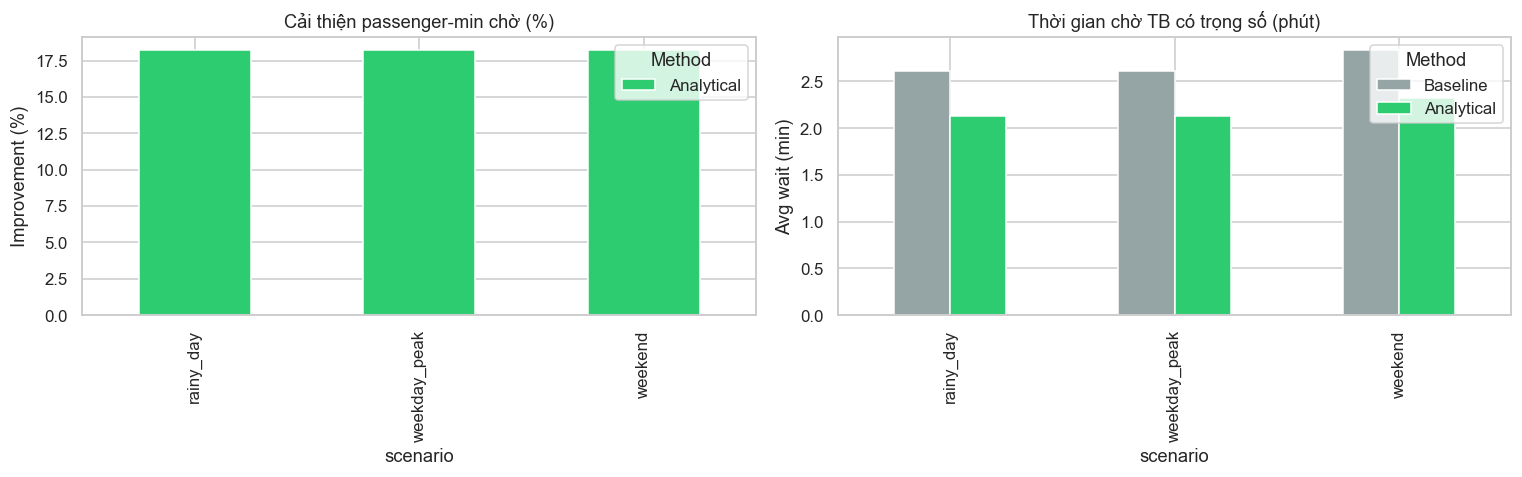

In [116]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

best_label = "Analytical" if USE_ANALYTICAL_OPT else "GA+Tabu"
methods_impr = [best_label] if USE_ANALYTICAL_OPT else ["GA", "GA+Tabu"]
pivot = results_df.pivot(index="scenario", columns="method", values="wait_improvement_pct")
pivot = pivot[[c for c in methods_impr if c in pivot.columns]]
pivot.plot(kind="bar", ax=axes[0], color=["#2ECC71"] if USE_ANALYTICAL_OPT else ["#3498DB", "#2ECC71"])
axes[0].set_title("Cải thiện passenger-min chờ (%)")
axes[0].set_ylabel("Improvement (%)"); axes[0].legend(title="Method")

cols_wait = ["Baseline", best_label]
pivot2 = results_df.pivot(index="scenario", columns="method", values="weighted_avg_wait_min")[cols_wait]
pivot2.plot(kind="bar", ax=axes[1], color=["#95A5A6", "#2ECC71"])
axes[1].set_title("Thời gian chờ TB có trọng số (phút)")
axes[1].set_ylabel("Avg wait (min)"); axes[1].legend(title="Method")

plt.tight_layout()
plt.savefig(OUT_DIR / "fig_improvement.png", dpi=120, bbox_inches="tight")
plt.show()


## 9b. Trade-off chờ ↔ fleet & phân tích độ nhạy λ

- **Trade-off**: optimizer giảm `passenger-min wait` bằng cách tăng số chuyến → `fleet_cost` tăng (λ × trips).
- **Độ nhạy λ**: tái tối ưu `weekday_peak` với λ ∈ `LAMBDA_GRID` (cùng seed GA).

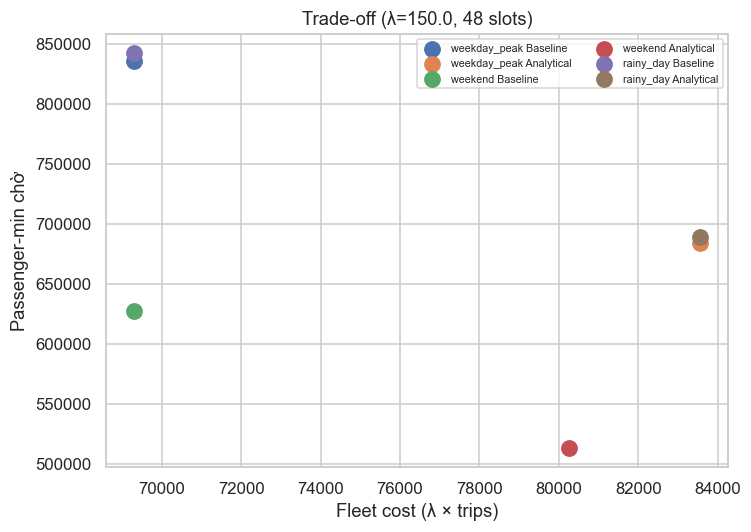

=== Độ nhạy λ (weekday_peak, auto-calibrate=True) ===
 lambda_eval  lambda_opt  total_trips  total_passenger_min_wait  total_fleet_cost  objective  baseline_objective  improvement_pct  pct_at_trips_max  elapsed_s
         100     1056.28        557.0                 683652.06           55700.0  739352.06           882201.75            16.19              50.0        0.0
         150     1056.28        557.0                 683652.06           83550.0  767202.06           905301.75            15.25              50.0        0.0
         200     1056.28        557.0                 683652.06          111400.0  795052.06           928401.75            14.36              50.0        0.0
         400     1056.28        557.0                 683652.06          222800.0  906452.06          1020801.75            11.20              50.0        0.0
         600     1056.28        557.0                 683652.06          334200.0 1017852.06          1113201.75             8.57              50.0    

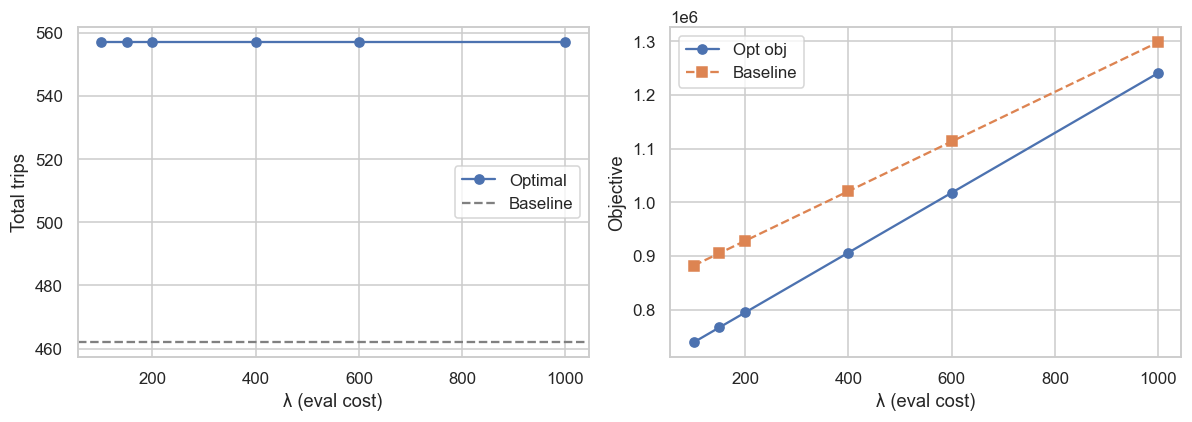

In [117]:
fig, ax = plt.subplots(figsize=(7, 5))
best_label = "Analytical" if USE_ANALYTICAL_OPT else "GA+Tabu"
for scen in SCENARIOS:
    sub = results_df[(results_df["scenario"] == scen) & (results_df["method"].isin(["Baseline", best_label]))]
    for method in ["Baseline", best_label]:
        r = sub[sub["method"] == method].iloc[0]
        ax.scatter(r["total_fleet_cost"], r["total_passenger_min_wait"],
                   s=100, label=f"{scen} {method}")
ax.set_xlabel("Fleet cost (λ × trips)")
ax.set_ylabel("Passenger-min chờ")
ax.set_title(f"Trade-off (λ={LAMBDA_COST}, {N_SLOTS} slots)")
ax.legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.savefig(OUT_DIR / "fig_tradeoff.png", dpi=120, bbox_inches="tight")
plt.show()

import time
lambda_rows = []
dem_peak = scenario_demand["weekday_peak"]
for lam in LAMBDA_GRID:
    t0 = time.time()
    lam_opt, sol_lam = resolve_lambda_for_demand(dem_peak, lam, auto_calibrate=LAMBDA_AUTO_CALIBRATE)
    m = evaluate_schedule(sol_lam, dem_peak, lambda_cost=lam)
    m_base = evaluate_schedule(baseline_trips, dem_peak, lambda_cost=lam)
    at_max = float((sol_lam >= TRIPS_MAX).mean())
    lambda_rows.append({
        "lambda_eval": lam,
        "lambda_opt": lam_opt,
        "total_trips": m["total_trips"],
        "total_passenger_min_wait": m["total_passenger_min_wait"],
        "total_fleet_cost": m["total_fleet_cost"],
        "objective": m["objective"],
        "baseline_objective": m_base["objective"],
        "improvement_pct": (m_base["objective"] - m["objective"]) / m_base["objective"] * 100,
        "pct_at_trips_max": at_max * 100,
        "elapsed_s": time.time() - t0,
    })

lambda_sensitivity_df = pd.DataFrame(lambda_rows)
print("=== Độ nhạy λ (weekday_peak, auto-calibrate={}) ===".format(LAMBDA_AUTO_CALIBRATE))
print(lambda_sensitivity_df.round(2).to_string(index=False))
lambda_sensitivity_df.to_csv(OUT_DIR / "lambda_sensitivity.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(lambda_sensitivity_df["lambda_eval"], lambda_sensitivity_df["total_trips"], "o-", label="Optimal")
axes[0].axhline(baseline_trips.sum(), color="grey", ls="--", label="Baseline")
axes[0].set_xlabel("λ (eval cost)"); axes[0].set_ylabel("Total trips"); axes[0].legend()

axes[1].plot(lambda_sensitivity_df["lambda_eval"], lambda_sensitivity_df["objective"], "o-", label="Opt obj")
axes[1].plot(lambda_sensitivity_df["lambda_eval"], lambda_sensitivity_df["baseline_objective"], "s--", label="Baseline")
axes[1].set_xlabel("λ (eval cost)"); axes[1].set_ylabel("Objective"); axes[1].legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "fig_lambda_sensitivity.png", dpi=120, bbox_inches="tight")
plt.show()


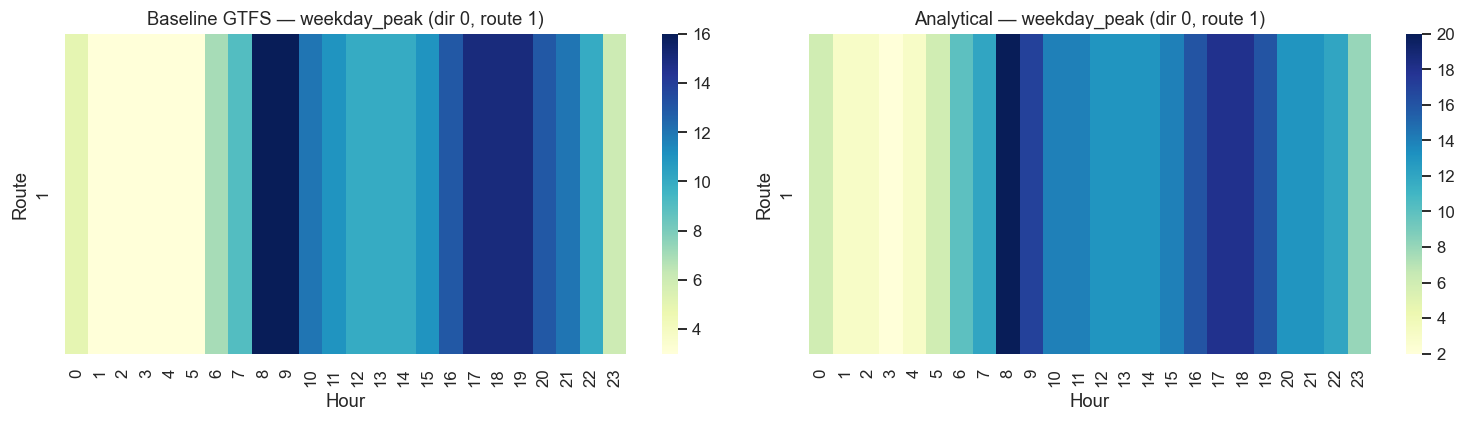

In [118]:
def reshape_trip_matrix(sol: np.ndarray, direction: int, routes: list) -> pd.DataFrame:
    sub = pd.DataFrame({
        "route": slot_route, "dir": slot_dir, "hour": slot_hour, "trips": sol
    })
    sub = sub[sub["dir"] == direction]
    return sub.pivot(index="route", columns="hour", values="trips").reindex(routes)

HEATMAP_ROUTES = list(OPT_ROUTES)
scen_to_show = "weekday_peak"
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, (method, sol) in zip(axes, [
    ("Baseline GTFS", baseline_trips),
    ("Analytical" if USE_ANALYTICAL_OPT else "GA+Tabu", opt_results[scen_to_show]),
]):
    m = reshape_trip_matrix(sol, direction=0, routes=HEATMAP_ROUTES)
    sns.heatmap(m, annot=False, fmt=".0f", cmap="YlGnBu", ax=ax)
    ax.set_title(f"{method} — {scen_to_show} (dir 0, route {SINGLE_ROUTE_ID})")
    ax.set_xlabel("Hour"); ax.set_ylabel("Route")
plt.tight_layout()
plt.savefig(OUT_DIR / f"fig_schedule_{scen_to_show}.png", dpi=120, bbox_inches="tight")
plt.show()


In [119]:
summary_metrics = {
    "n_slots": int(N_SLOTS),
    "n_routes": int(len(OPT_ROUTES)),
    "n_hours": int(len(OPT_HOURS)),
    "routes": list(OPT_ROUTES),
    "opt_method": "Analytical" if USE_ANALYTICAL_OPT else "GA+Tabu",
    "n_headway_fallback": int(n_fallback),
    "scenarios": list(scenario_demand.keys()),
    "lambda_cost_default": float(LAMBDA_COST),
    "lambda_used": {k: float(v) for k, v in lambda_used.items()},
    "split_demand_by_direction": bool(SPLIT_DEMAND_BY_DIRECTION),
    "bound_status": bound_status,
    "opt_target": str(globals().get("OPT_TARGET", "objective")),
    "balanced_weights": globals().get("BALANCED_WEIGHTS", {"wait": 0.5, "cost": 0.5}),
    "lambda_candidates": [float(x) for x in globals().get("LAMBDA_CANDIDATES", LAMBDA_GRID)],
    "baseline": {s: baseline_metrics[s] for s in scenario_demand},
    "optimized": {s: evaluate_schedule(opt_results[s], scenario_demand[s])
                  for s in scenario_demand},
    "nn_eval": nn_eval_metrics,
    "lambda_sensitivity_weekday_peak": lambda_sensitivity_df.to_dict(orient="records"),
}
with open(OUT_DIR / "baseline_metrics.json", "w", encoding="utf-8") as f:
    json.dump(summary_metrics, f, indent=2)
print("Đã ghi:", OUT_DIR / "baseline_metrics.json")


Đã ghi: outputs_single_route\baseline_metrics.json


## 10. Kết luận & Discussion

### Tổng kết (single route)

- **Phạm vi**: 1 tuyến × 2 chiều × 24 giờ = 48 slot; ridership ~731 ngày.
- **NN**: MLP + lag features; demand route×hour, **chia theo chiều** bằng tỷ lệ chuyến GTFS.
- **Tối ưu**: analytical per-slot; auto-calibrate λ khi quá nhiều slot dính `TRIPS_MAX`.
- **Output**: `results_summary.csv`, `nn_eval_summary.csv`, `lambda_sensitivity.csv`.

### Hạn chế

- Chia chiều bằng proxy GTFS, chưa có ridership theo direction thực.
- Waiting time = headway/2; chưa ràng buộc fleet/crew chung.

### Hướng mở rộng

- Ridership theo chiều (turnstile/OD); ràng buộc vận hành; multi-route.


## 12. Ghi chú vận hành

- `OPT_TARGET`: `wait` | `cost` | `objective` | `balanced`
- `LAMBDA_AUTO_CALIBRATE` + `TARGET_MAX_BIND_FRACTION`: tránh lời giải dính trần trip
- `SPLIT_DEMAND_BY_DIRECTION`: bật/tắt chia demand theo GTFS
- Khối **sample 2026**: kiểm thử factors ngày cụ thể


In [120]:
# --- Inference cho factors mẫu 2026 và suy ra lịch trình theo từng ngày ---

TEST_FACTORS_FILE = DATA_DIR / "factors_hourly_2026_samples.csv"


def _prepare_daily_features_from_factors(factors_day: pd.DataFrame) -> pd.DataFrame:
    """Chuẩn hóa factors theo schema model, cross-join route x dir x hour."""
    for c in ["date", "hour"]:
        if c not in factors_day.columns:
            raise ValueError(f"Thiếu cột bắt buộc trong factors mẫu: {c}")

    factors_day = factors_day.copy()
    factors_day["hour"] = pd.to_numeric(factors_day["hour"], errors="coerce").fillna(-1).astype(int)
    factors_day = factors_day[factors_day["hour"].isin(OPT_HOURS)].copy()
    factors_day = factors_day.sort_values(["date", "hour"]).drop_duplicates(subset=["date", "hour"], keep="last")

    grid = pd.DataFrame({
        "route_id": np.repeat(OPT_ROUTES, len(DIRECTIONS) * len(OPT_HOURS)),
        "direction": np.tile(np.repeat(DIRECTIONS, len(OPT_HOURS)), len(OPT_ROUTES)),
        "hour": np.tile(OPT_HOURS, len(OPT_ROUTES) * len(DIRECTIONS)),
    })
    feat = grid.merge(factors_day.drop(columns=["date"]).copy(), on="hour", how="left")

    if "is_weekend" not in feat.columns:
        feat["is_weekend"] = 0
    for c in ["is_monday", "is_friday", "is_us_holiday", "is_major_event_window"]:
        if c not in feat.columns:
            feat[c] = 0

    feat["route_idx"] = feat["route_id"].map(route_to_idx)
    feat["route_idx"] = pd.to_numeric(feat["route_idx"], errors="coerce").fillna(0).astype(int)

    fb_route_hour = fallback.copy()
    fb_route = df.groupby(["route_id", "is_weekend"], as_index=False)["demand"].median().rename(columns={"demand": "fb_route_weekend"})
    fb_hour = df.groupby(["hour", "is_weekend"], as_index=False)["demand"].median().rename(columns={"demand": "fb_hour_weekend"})
    fb_global = float(pd.to_numeric(df["demand"], errors="coerce").dropna().median())
    if not np.isfinite(fb_global) or fb_global <= 0:
        fb_global = 100.0

    feat = feat.merge(baseline_lookup, on=["route_id", "hour", "is_weekend"], how="left")
    feat = feat.merge(fb_route_hour, on=["route_id", "hour"], how="left")
    feat = feat.merge(fb_route, on=["route_id", "is_weekend"], how="left")
    feat = feat.merge(fb_hour, on=["hour", "is_weekend"], how="left")

    feat["baseline_demand"] = pd.to_numeric(feat.get("baseline_demand"), errors="coerce")
    feat["fallback_demand"] = pd.to_numeric(feat.get("fallback_demand"), errors="coerce")
    feat["fb_route_weekend"] = pd.to_numeric(feat.get("fb_route_weekend"), errors="coerce")
    feat["fb_hour_weekend"] = pd.to_numeric(feat.get("fb_hour_weekend"), errors="coerce")
    feat["baseline_demand"] = feat["baseline_demand"].fillna(feat["fallback_demand"]).fillna(feat["fb_route_weekend"]).fillna(feat["fb_hour_weekend"]).fillna(fb_global)

    for c in NUM_FEATURES:
        if c not in feat.columns:
            feat[c] = 0.0
        feat[c] = pd.to_numeric(feat[c], errors="coerce")
        med = float(pd.to_numeric(df[c], errors="coerce").median()) if c in df.columns else 0.0
        if not np.isfinite(med):
            med = 0.0
        feat[c] = feat[c].fillna(med)

    feat["baseline_demand"] = np.clip(feat["baseline_demand"].to_numpy(dtype=float), 1e-6, None)
    feat["log_baseline"] = np.log1p(feat["baseline_demand"])
    return feat.reset_index(drop=True)


def demand_from_factors_day(factors_day: pd.DataFrame) -> np.ndarray:
    feat = _prepare_daily_features_from_factors(factors_day)
    # Dự báo trên unique route×hour
    feat_u = feat.drop_duplicates(subset=["route_id", "hour"]).copy()
    Xn = scaler.transform(feat_u[NUM_FEATURES])
    pred = predict_demand(feat_u["route_idx"].values, Xn, feat_u["log_baseline"].values)
    pred = np.clip(
        np.nan_to_num(pred, nan=float(np.nanmedian(feat_u["baseline_demand"]))),
        0.0, None,
    )
    route_hour = feat_u[["route_id", "hour"]].assign(demand=pred)
    return allocate_demand_to_slots(route_hour)


if not TEST_FACTORS_FILE.exists():
    raise FileNotFoundError(f"Không tìm thấy file factors mẫu: {TEST_FACTORS_FILE}")

factors_test = pd.read_csv(TEST_FACTORS_FILE)
for c in ["date", "hour"]:
    if c not in factors_test.columns:
        raise ValueError(f"File factors mẫu thiếu cột bắt buộc: {c}")

factors_test["date"] = factors_test["date"].astype(str)
factors_test["hour"] = pd.to_numeric(factors_test["hour"], errors="coerce").fillna(-1).astype(int)

sample_dates = sorted(factors_test["date"].dropna().unique().tolist())
if not sample_dates:
    raise ValueError("Không có ngày hợp lệ trong factors mẫu")

print("Test dates:", sample_dates)

sample_rows = []
schedule_rows = []
opt_target, policy_weights, lambda_candidates = resolve_opt_policy()

for day in sample_dates:
    day_df = factors_test[factors_test["date"] == day].copy()
    demand_day = demand_from_factors_day(day_df)

    best_sol, best_lam, best_eval, base_m, _ = select_best_lambda_solution(
        demand=demand_day,
        baseline_trips_arr=baseline_trips,
        lambda_eval=float(LAMBDA_COST),
        opt_target=opt_target,
        weights=policy_weights,
        lambda_candidates=lambda_candidates,
    )

    sample_rows.append({
        "date": day,
        "target": opt_target,
        "lambda_eval": float(LAMBDA_COST),
        "lambda_opt": float(best_lam),
        "baseline_objective": float(base_m["objective"]),
        "optimized_objective": float(best_eval["objective"]),
        "objective_improvement_pct": pct_improve(base_m["objective"], best_eval["objective"]),
        "baseline_wait": float(base_m["total_passenger_min_wait"]),
        "optimized_wait": float(best_eval["total_passenger_min_wait"]),
        "wait_improvement_pct": pct_improve(base_m["total_passenger_min_wait"], best_eval["total_passenger_min_wait"]),
        "baseline_fleet_cost": float(base_m["total_fleet_cost"]),
        "optimized_fleet_cost": float(best_eval["total_fleet_cost"]),
        "optimized_total_trips": float(best_eval["total_trips"]),
    })

    schedule_rows.append(pd.DataFrame({
        "date": day,
        "route": slot_route,
        "direction": slot_dir,
        "hour": slot_hour,
        "baseline_trips": baseline_trips,
        "opt_trips": best_sol,
        "predicted_demand": demand_day,
        "lambda_opt": best_lam,
        "target": opt_target,
    }))

sample_summary_df = pd.DataFrame(sample_rows).sort_values("date").reset_index(drop=True)
sample_schedule_df = pd.concat(schedule_rows, ignore_index=True)

sample_summary_file = OUT_DIR / "sample_2026_results_summary.csv"
sample_schedule_file = OUT_DIR / "sample_2026_schedule_by_date.csv"
sample_summary_df.to_csv(sample_summary_file, index=False)
sample_schedule_df.to_csv(sample_schedule_file, index=False)

print("\\n=== Kết quả mẫu 2026 ===")
print(sample_summary_df.round(3).to_string(index=False))
print("\\nĐã ghi:")
print(" -", sample_summary_file)
print(" -", sample_schedule_file)


Test dates: ['2026-01-15', '2026-03-28', '2026-05-12']
\n=== Kết quả mẫu 2026 ===
      date   target  lambda_eval  lambda_opt  baseline_objective  optimized_objective  objective_improvement_pct  baseline_wait  optimized_wait  wait_improvement_pct  baseline_fleet_cost  optimized_fleet_cost  optimized_total_trips
2026-01-15 balanced        150.0       260.0          537636.769           452861.538                     15.768     468336.769      363311.538                22.425              69300.0               89550.0                  597.0
2026-03-28 balanced        150.0       260.0          394928.456           336223.390                     14.865     325628.456      250123.390                23.187              69300.0               86100.0                  574.0
2026-05-12 balanced        150.0       260.0          537636.769           452861.538                     15.768     468336.769      363311.538                22.425              69300.0               89550.0              